# Compare-Map Visualisations

In [30]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

COMPARE_OUTPUT_DIR_NAME = "compare-map-700"


def find_compare_output_dir() -> Path:
    candidates: list[Path] = []

    if "__file__" in globals():
        candidates.append(Path(__file__).resolve().parent)

    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        candidates.append(Path(vscode_notebook).expanduser().resolve().parent)

    cwd = Path.cwd().resolve()
    candidates.extend(
        [
            cwd,
            cwd / "nas" / COMPARE_OUTPUT_DIR_NAME,
            cwd.parent / COMPARE_OUTPUT_DIR_NAME,
        ]
    )

    for candidate in candidates:
        if candidate.exists() and any(candidate.glob("*/metrics.jsonl")):
            return candidate

    raise FileNotFoundError(
        "Could not locate compare output directory. "
        f"Set BASE_OUTPUT_DIR manually to the folder containing metrics.jsonl subdirectories. Tried: {candidates}"
    )


BASE_OUTPUT_DIR = find_compare_output_dir()
print(f"Using compare output directory: {BASE_OUTPUT_DIR}")


def latest_run_dir(base_dir: Path = BASE_OUTPUT_DIR) -> Path:
    candidates = sorted(
        [path for path in base_dir.glob("*/metrics.jsonl")],
        key=lambda p: p.stat().st_mtime,
    )
    if not candidates:
        raise FileNotFoundError(
            f"No metrics.jsonl files found under {base_dir}. Run nas/compare-track.py first."
        )
    return candidates[-1].parent

RUN_DIR_OVERRIDE: Path | str | None = "f926b9"  # e.g., "compare_20260410T133741"
# RUN_DIR_OVERRIDE: Path | str | None = None


def resolve_run_dir() -> Path:
    if RUN_DIR_OVERRIDE:
        candidate = Path(RUN_DIR_OVERRIDE)
        if not candidate.is_absolute():
            candidate = BASE_OUTPUT_DIR / candidate
        if candidate.is_file():
            candidate = candidate.parent
        if not candidate.exists():
            raise FileNotFoundError(
                f"Override directory {candidate} was not found. Update RUN_DIR_OVERRIDE."
            )
        metrics_file = candidate / "metrics.jsonl"
        if not metrics_file.exists():
            raise FileNotFoundError(
                f"{metrics_file} was not found; choose a directory containing metrics.jsonl."
            )
        return candidate
    return latest_run_dir()

RUN_DIR = resolve_run_dir()
METRICS_FILE = RUN_DIR / "metrics.jsonl"
print(f"Using metrics from: {RUN_DIR}")

with METRICS_FILE.open("r", encoding="utf-8") as fh:
    METRIC_RECORDS = [json.loads(line) for line in fh if line.strip()]

if not METRIC_RECORDS:
    raise RuntimeError(f"{METRICS_FILE} is empty; rerun compare-track.")

def display_map_name(map_name: str) -> str:
    return Path(map_name).name


rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        rows.append(
            {
                "map": map_name,
                "map_label": display_map_name(map_name),
                "arch": run["label"],
                "rmse": run.get("rmse"),
            }
        )

df = pd.DataFrame(rows)
pivot = df.pivot_table(index="arch", columns="map_label", values="rmse")
pivot = pivot.sort_index()

def default_highlight_arch(index: pd.Index) -> str | None:
    for candidate in (RUN_DIR.name, "arch8"):
        if candidate in index:
            return candidate
    return None


HIGHLIGHT_ARCH = default_highlight_arch(pivot.index)
print(f"Loaded RMSE table with shape {pivot.shape} (arches x maps).")


Using compare output directory: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map-700
Using metrics from: /Users/zayahcortright/DAX.nosync/f1tenth_ng_zc/nas/compare-map-700/f926b9
Loaded RMSE table with shape (8, 7) (arches x maps).


## Continuous metric tables


In [31]:
metric_specs = {
    "crosstrack_rmse_m": {
        "title": "Cross-track RMSE",
        "ylabel": "Cross-track RMSE (m)",
        "table_title": "Cross-track RMSE (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_mean_m": {
        "title": "Mean cross-track error",
        "ylabel": "Mean cross-track error (m)",
        "table_title": "Mean cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_std_m": {
        "title": "Cross-track variability",
        "ylabel": "Cross-track std (m)",
        "table_title": "Cross-track std (m)",
        "ylim_bottom": 0.0,
    },
    "crosstrack_max_m": {
        "title": "Maximum cross-track error",
        "ylabel": "Max cross-track error (m)",
        "table_title": "Max cross-track error (m)",
        "ylim_bottom": 0.0,
    },
    "heading_error_rmse_deg": {
        "title": "Heading-error RMSE",
        "ylabel": "Heading-error RMSE (deg)",
        "table_title": "Heading-error RMSE (deg)",
        "ylim_bottom": 0.0,
    },
    "heading_error_max_deg": {
        "title": "Maximum heading error",
        "ylabel": "Max heading error (deg)",
        "table_title": "Max heading error (deg)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_m": {
        "title": "Minimum wall clearance",
        "ylabel": "Min wall distance (m)",
        "table_title": "Min wall distance (m)",
        "ylim_bottom": 0.0,
    },
    "wall_min_distance_risk": {
        "title": "Wall clearance risk",
        "ylabel": "Wall clearance risk (normalized)",
        "table_title": "Wall clearance risk (normalized)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_mean_rad_s": {
        "title": "Mean steering-rate effort",
        "ylabel": "Mean steering rate (rad/s)",
        "table_title": "Mean steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_std_rad_s": {
        "title": "Steering-rate variability",
        "ylabel": "Steering-rate std (rad/s)",
        "table_title": "Steering-rate std (rad/s)",
        "ylim_bottom": 0.0,
    },
    "steering_rate_max_rad_s": {
        "title": "Maximum steering-rate spike",
        "ylabel": "Max steering rate (rad/s)",
        "table_title": "Max steering rate (rad/s)",
        "ylim_bottom": 0.0,
    },
    "speed_mean_m_s": {
        "title": "Mean speed",
        "ylabel": "Mean speed (m/s)",
        "table_title": "Mean speed (m/s)",
        "ylim_bottom": 0.0,
    },
    "speed_std_m_s": {
        "title": "Speed variability",
        "ylabel": "Speed std (m/s)",
        "table_title": "Speed std (m/s)",
        "ylim_bottom": 0.0,
    },
}

metric_rows: list[dict[str, object]] = []
for record in METRIC_RECORDS:
    map_name = record["map"]
    for run in record["runs"]:
        row = {"map": map_name, "map_label": display_map_name(map_name), "arch": run["label"]}
        for metric_key in metric_specs:
            row[metric_key] = run.get(metric_key)
        metric_rows.append(row)

metric_df = pd.DataFrame(metric_rows)
if "wall_min_distance_m" in metric_df.columns:
    wall_span = metric_df["wall_min_distance_m"].max() - metric_df["wall_min_distance_m"].min()
    if wall_span == 0:
        metric_df["wall_min_distance_risk"] = 0.5
    else:
        metric_df["wall_min_distance_risk"] = 1.0 - (
            (metric_df["wall_min_distance_m"] - metric_df["wall_min_distance_m"].min()) / wall_span
        )
metric_pivots = {
    metric_key: (
        metric_df
        .pivot_table(index="arch", columns="map_label", values=metric_key)
        .reindex(index=pivot.index, columns=pivot.columns)
    )
    for metric_key in metric_specs
    if metric_key in metric_df.columns and metric_df[metric_key].notna().any()
}

for metric_key, metric_pivot in metric_pivots.items():
    print(metric_specs[metric_key]["table_title"])
    display(
        metric_pivot.style
        .format("{:.4f}")
        .background_gradient(axis=0, cmap="YlGnBu")
        .set_properties(**{"text-align": "center"})
    )


Cross-track RMSE (m)


map_label,MexicoCity,Monza,Nuerburgring,Shanghai,Silverstone,Sochi,Spa
arch,,,,,,,
arch1,0.1375,0.0935,0.0950,0.1378,0.0936,0.1021,0.0926
arch2,0.1257,0.0958,0.0994,0.1381,0.0945,0.0871,0.0920
arch3,0.1478,0.0885,0.1085,0.1635,0.0937,0.1236,0.0817
arch4,0.1483,0.0934,0.1445,0.1667,0.1223,0.1244,0.1091
arch5,0.1402,0.0968,0.1406,0.1597,0.1298,0.1225,0.1182
arch6,0.1349,0.0965,0.1384,0.1499,0.1326,0.1244,0.1176
arch7,0.1406,0.0974,0.1421,0.1724,0.1279,0.1214,0.1153
f926b9,0.1970,0.1369,0.2420,0.3480,0.1573,0.1378,0.1660


Mean cross-track error (m)


map_label,MexicoCity,Monza,Nuerburgring,Shanghai,Silverstone,Sochi,Spa
arch,,,,,,,
arch1,0.0981,0.0509,0.0712,0.0994,0.0738,0.0671,0.0562
arch2,0.0901,0.0643,0.0746,0.1010,0.0694,0.0630,0.0649
arch3,0.0800,0.0419,0.0633,0.0811,0.0511,0.0687,0.0438
arch4,0.0945,0.0581,0.0945,0.1102,0.0822,0.0775,0.0695
arch5,0.0885,0.0659,0.0917,0.1020,0.0882,0.0775,0.0763
arch6,0.0859,0.0667,0.0918,0.0964,0.0911,0.0802,0.0764
arch7,0.0882,0.0646,0.0935,0.1084,0.0872,0.0769,0.0739
f926b9,0.1442,0.1008,0.1830,0.2951,0.1225,0.1032,0.1217


Cross-track std (m)


...

map_label,MexicoCity,Monza,Nuerburgring,Shanghai,Silverstone,Sochi,Spa
arch,,,,,,,
arch1,17.1299,7.6242,10.9382,15.3127,10.8651,13.7294,10.4538
arch2,12.2261,17.9866,8.0391,16.6692,10.6974,10.8970,14.5595
arch3,11.3636,10.3173,8.6055,26.9412,14.0727,10.3984,7.9956
arch4,5.5411,7.0207,4.7663,7.5755,4.9404,6.4324,9.2540
arch5,46.1084,39.2765,5.0764,72.6791,6.0180,3.7310,5.4216
arch6,29.7852,21.7554,4.5122,70.6885,6.6542,7.8397,10.8909
arch7,18.3024,18.4959,6.9821,72.2691,11.3293,6.2641,12.4035
f926b9,14.5829,21.9561,32.1287,41.6836,12.4413,17.9430,25.4849


Mean speed (m/s)


map_label,MexicoCity,Monza,Nuerburgring,Shanghai,Silverstone,Sochi,Spa
arch,,,,,,,
arch1,3.9132,4.2548,4.0116,3.9916,3.9442,4.0368,4.1139
arch2,3.6286,3.8270,3.7475,3.6510,3.6835,3.7687,3.7749
arch3,3.8235,4.1724,3.9707,3.9052,3.9958,3.8901,4.0762
arch4,3.8153,4.1706,3.9720,3.9445,3.9815,3.9517,4.0754
arch5,3.8741,4.0876,4.0006,3.9635,3.9590,3.9635,4.0379
arch6,3.8985,4.0847,4.0003,3.9921,3.9528,3.9436,4.0257
arch7,3.8506,4.0700,3.9854,3.9345,3.9562,3.9524,4.0404
f926b9,3.3053,3.6551,3.2143,2.9066,3.6005,3.5374,3.6056


Speed std (m/s)


map_label,MexicoCity,Monza,Nuerburgring,Shanghai,Silverstone,Sochi,Spa
arch,,,,,,,
arch1,0.8911,0.6932,0.7752,0.8065,0.6742,0.7876,0.7519
arch2,0.8516,0.7417,0.7592,0.7845,0.7809,0.7484,0.7372
arch3,0.9850,0.7320,0.8026,0.9096,0.7719,0.8767,0.7453
arch4,0.9579,0.7528,0.8487,0.9090,0.8066,0.8629,0.7933
arch5,0.9622,0.7278,0.8318,0.9002,0.8028,0.8502,0.7837
arch6,0.9638,0.7334,0.8265,0.9055,0.8184,0.8415,0.7743
arch7,0.9668,0.7185,0.8273,0.9240,0.7983,0.8449,0.7789
f926b9,0.7292,0.6180,0.6226,0.5531,0.7193,0.6995,0.7383


## Connected metric comparisons

Each plot below matches the RMSE comparison style: maps on the x-axis, one line per architecture, and arch8 highlighted in red.


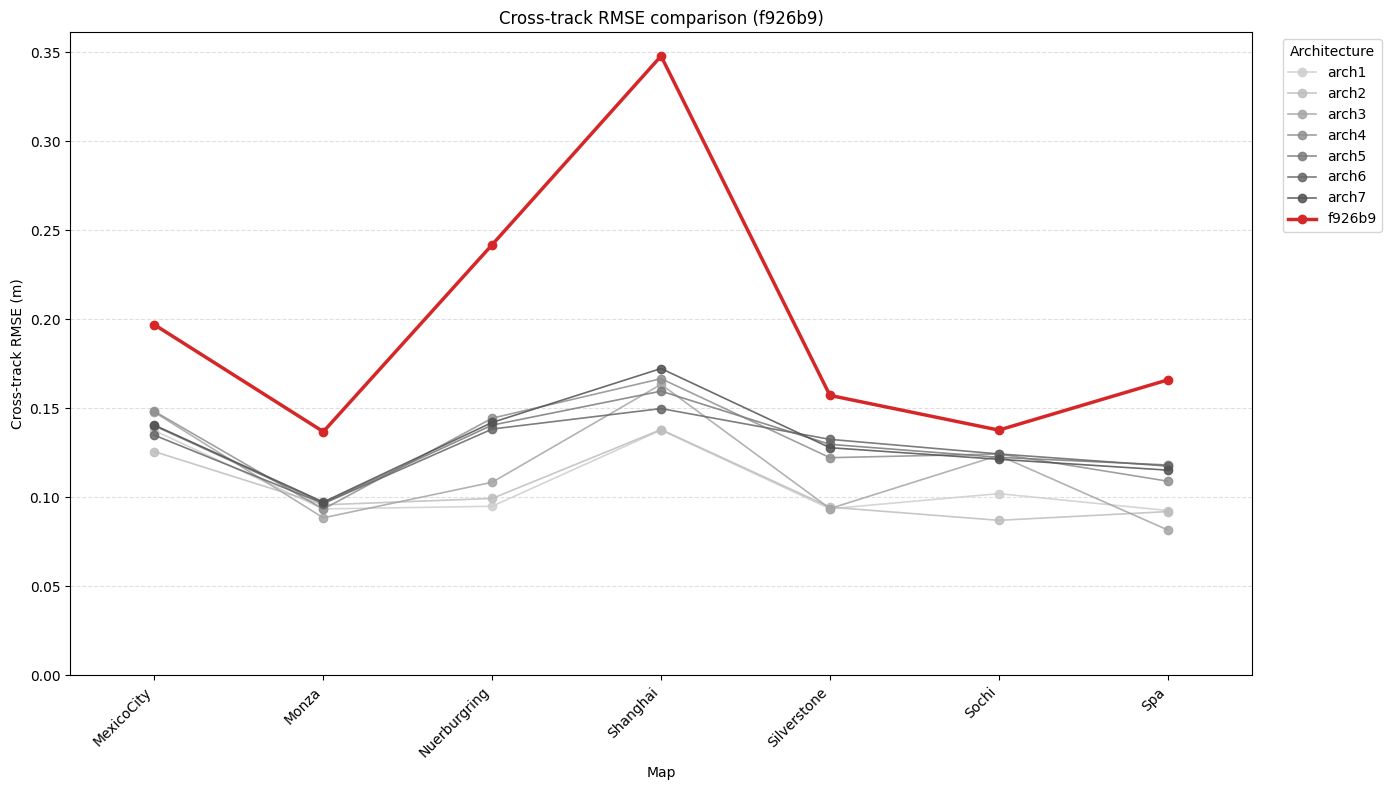

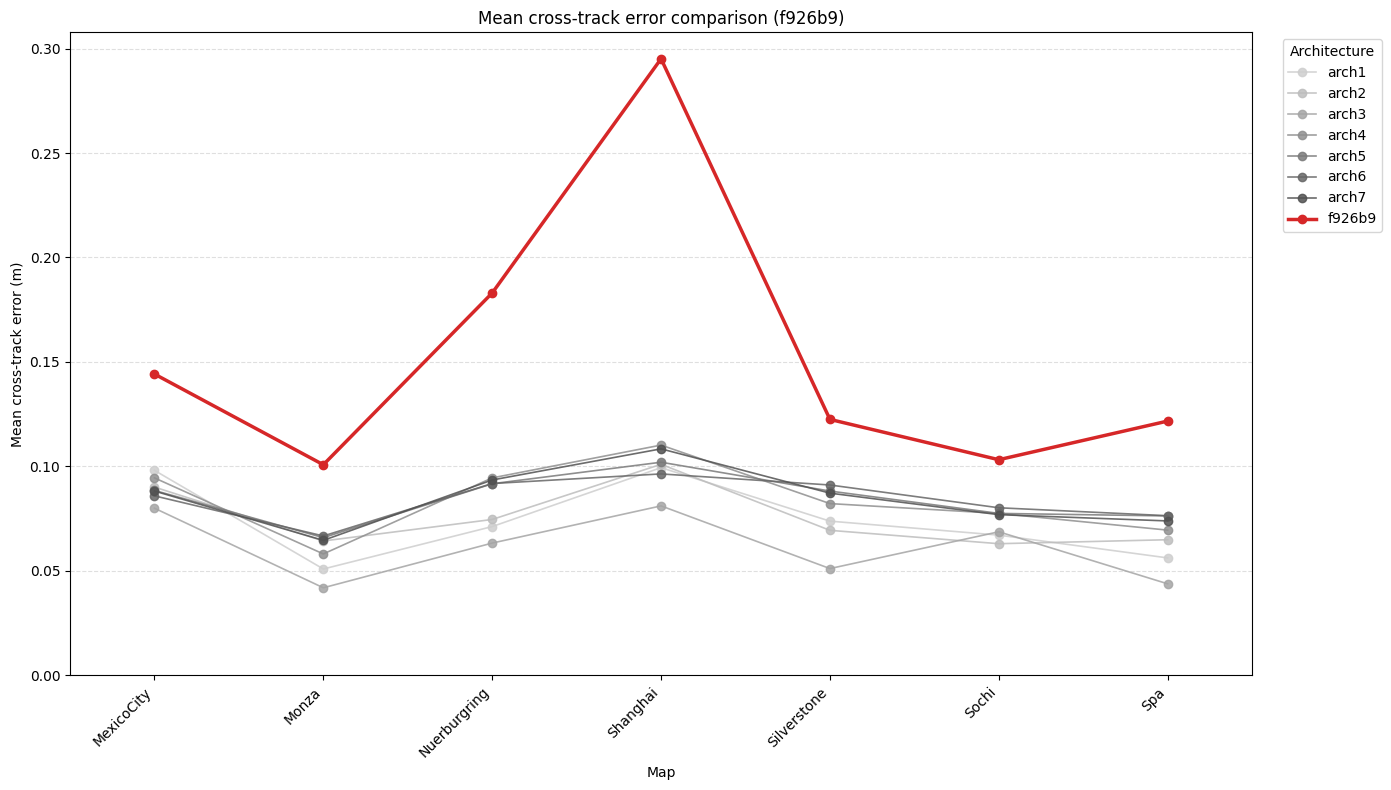

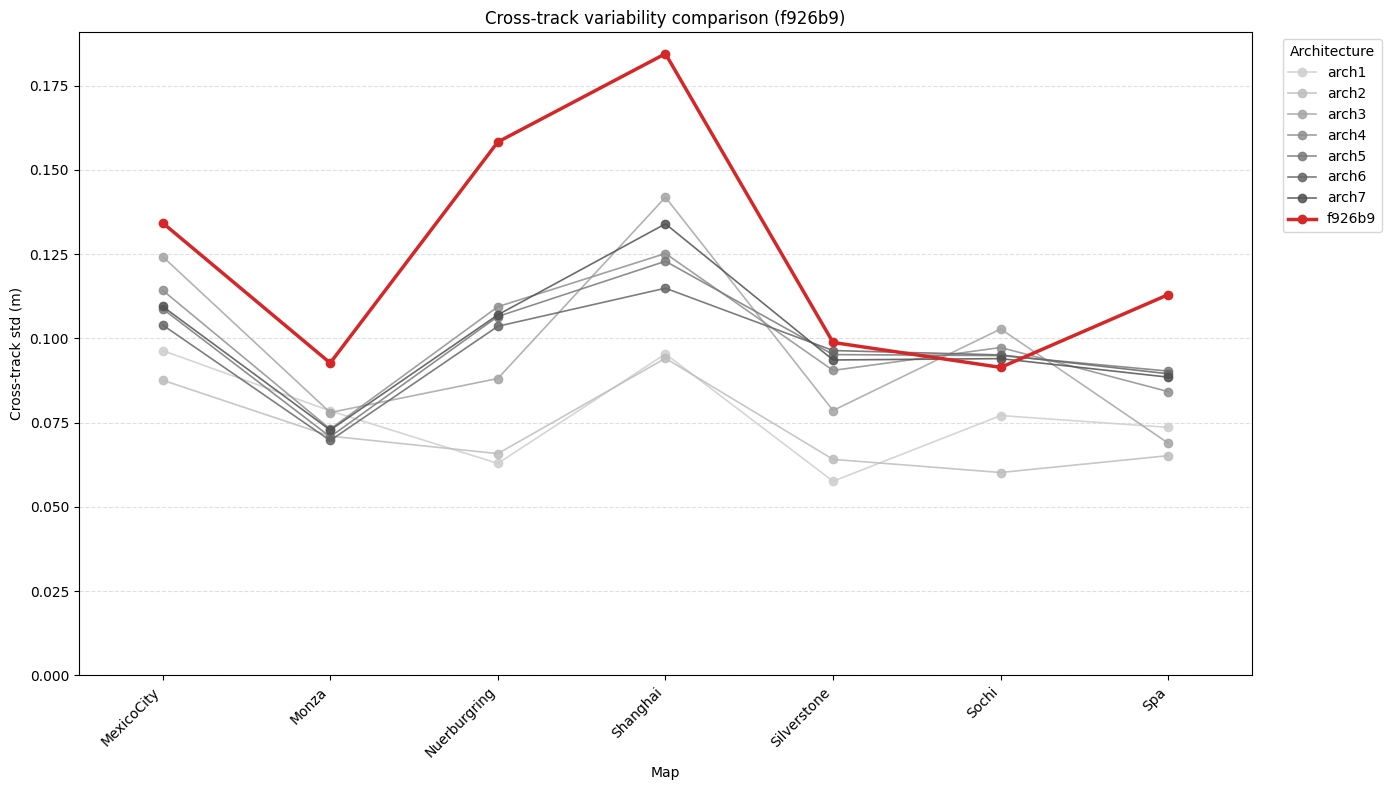

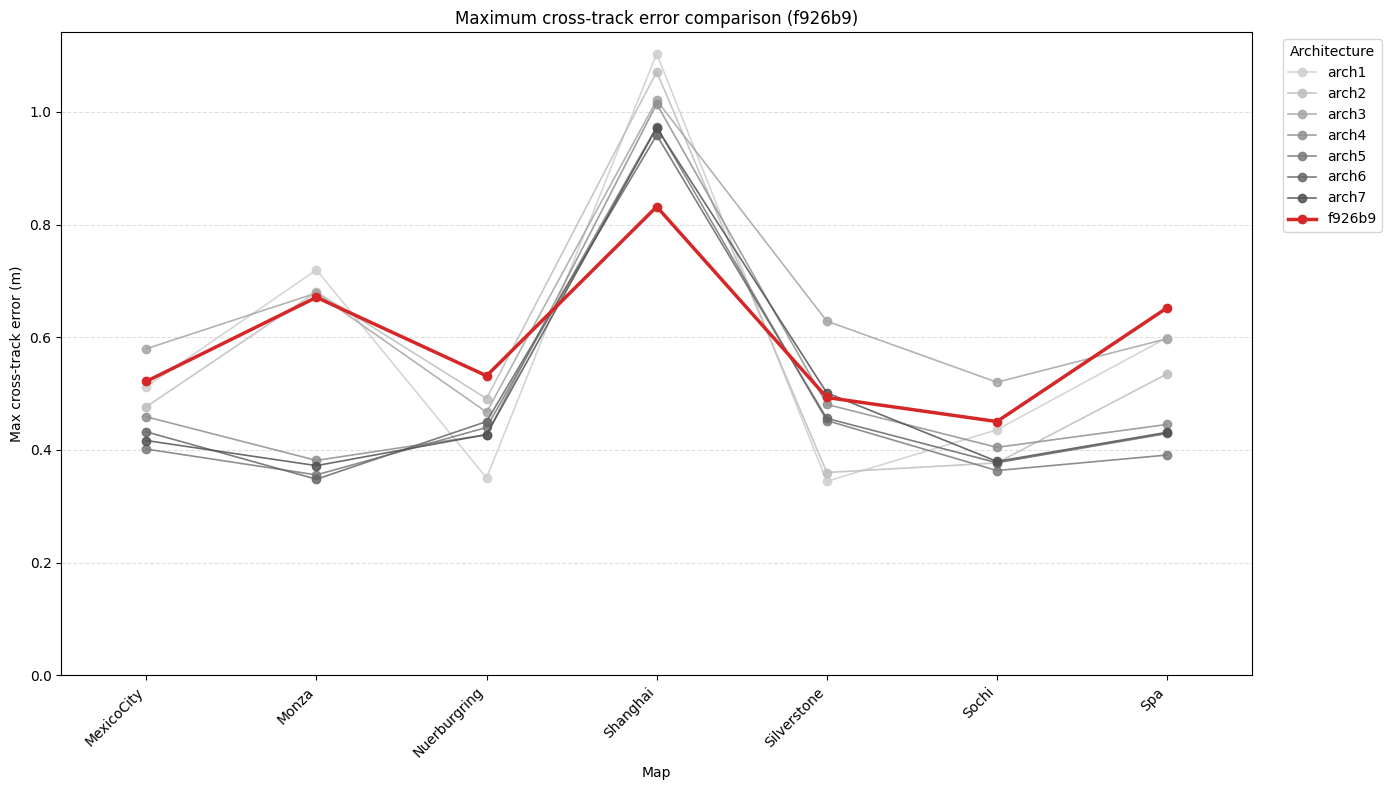

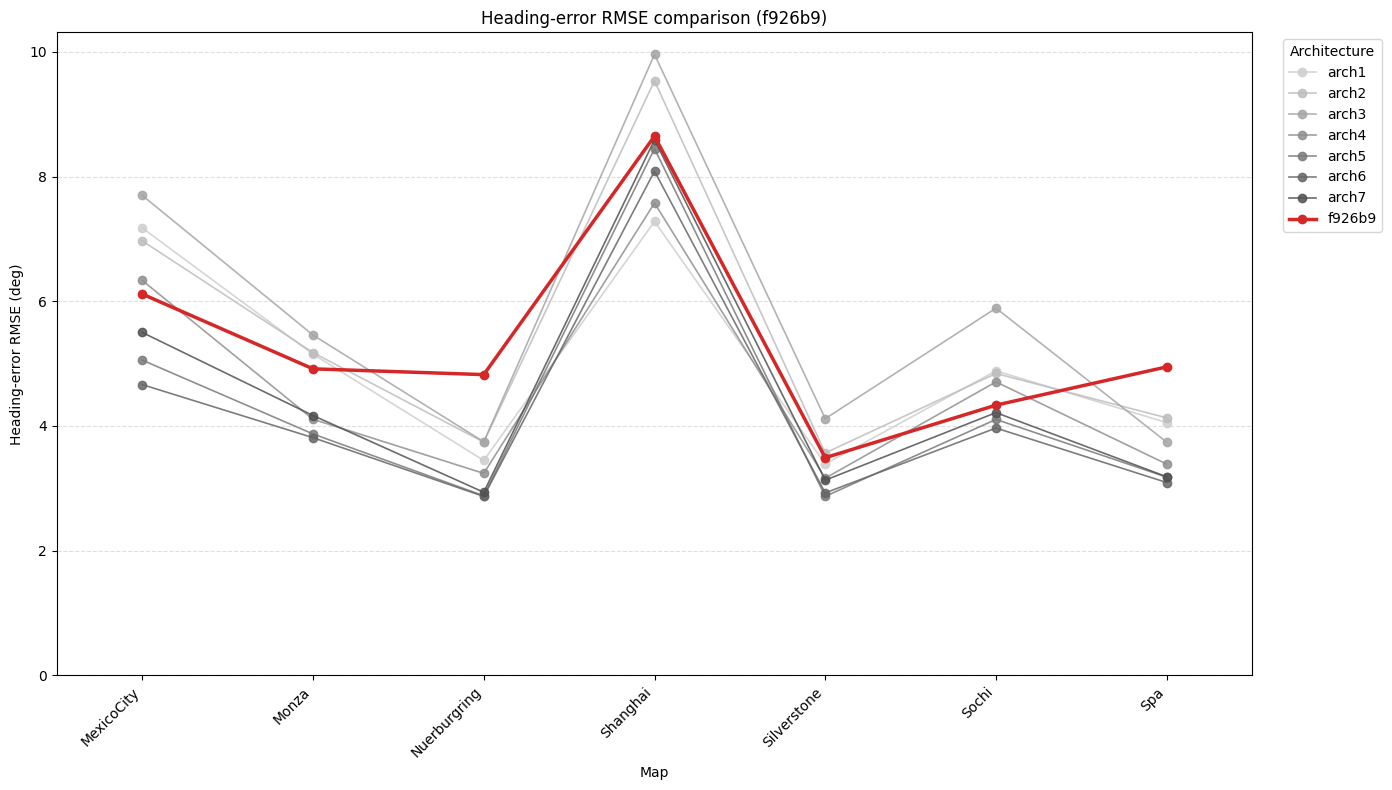

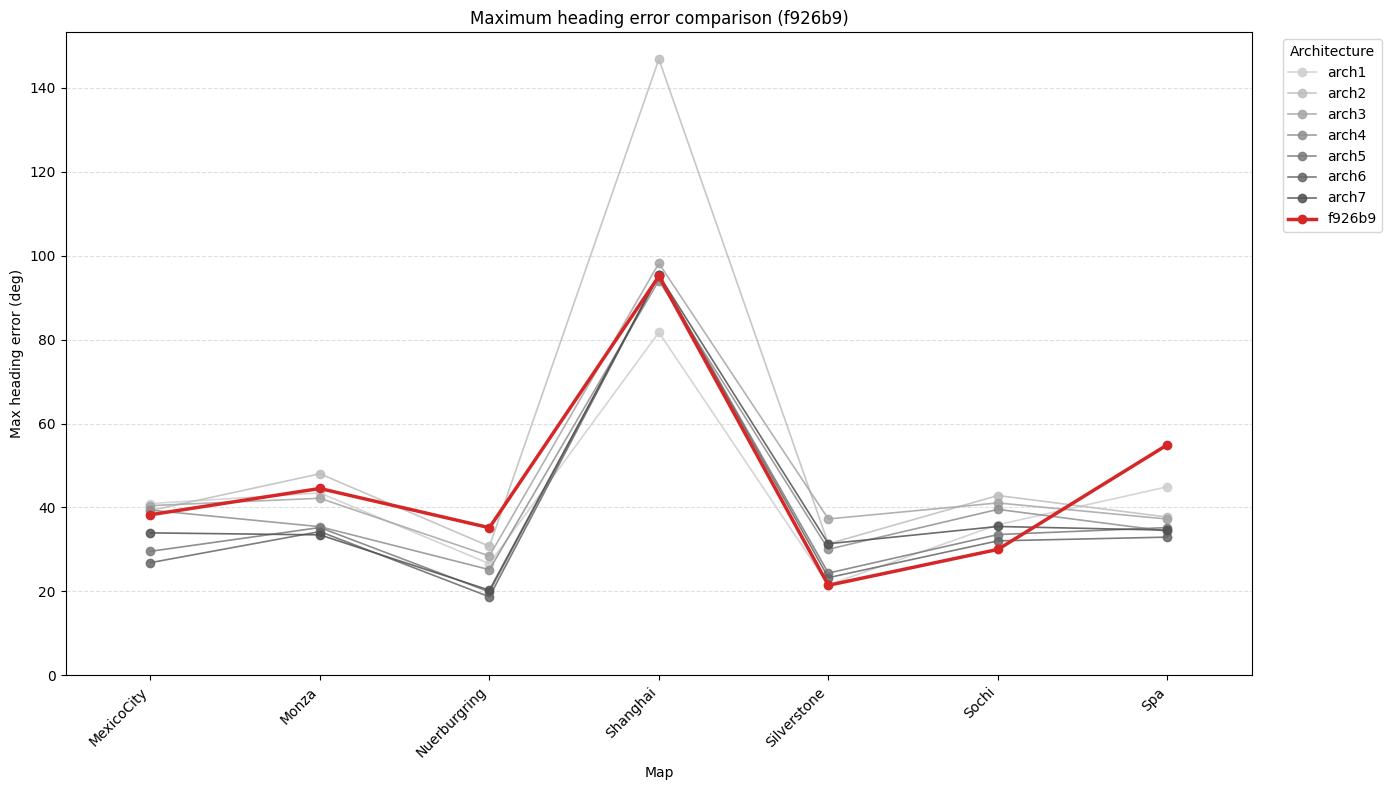

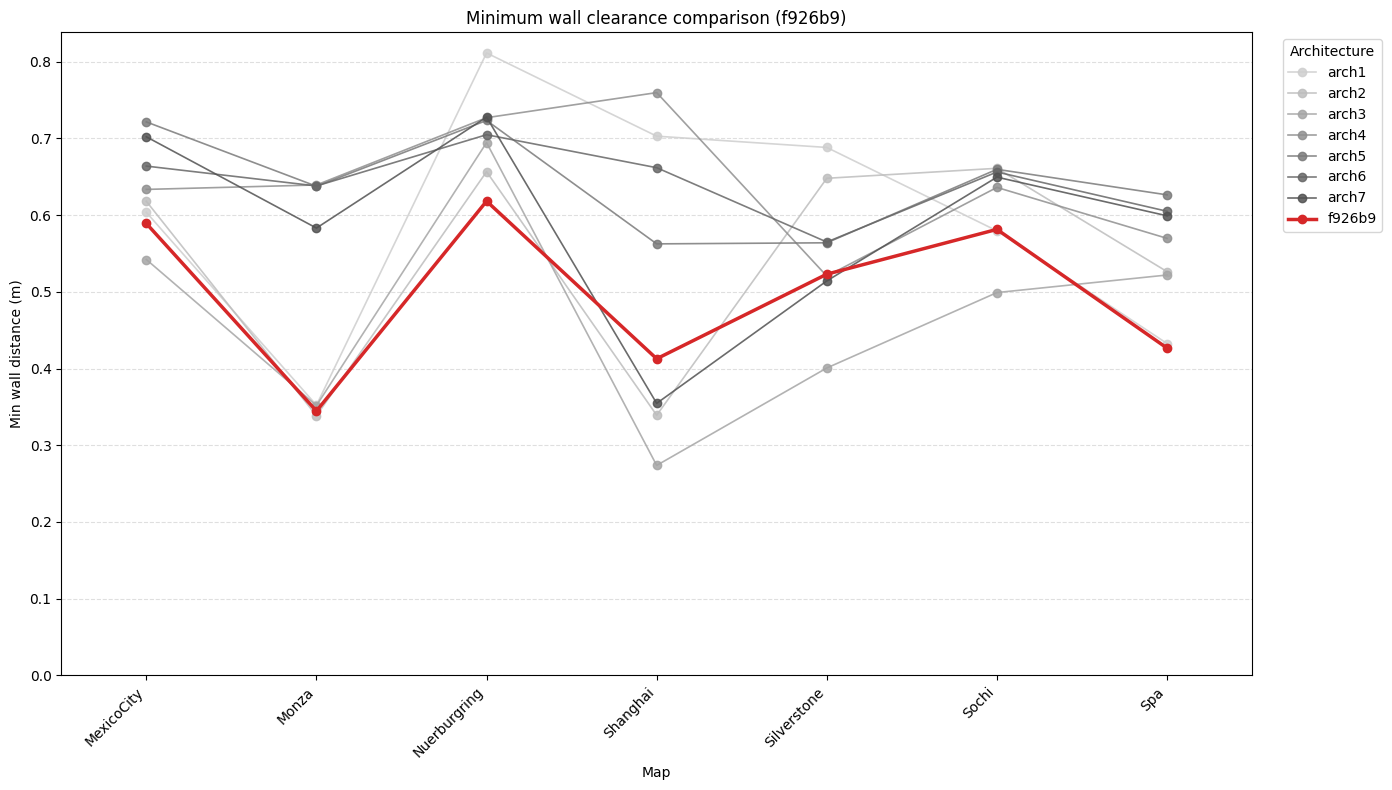

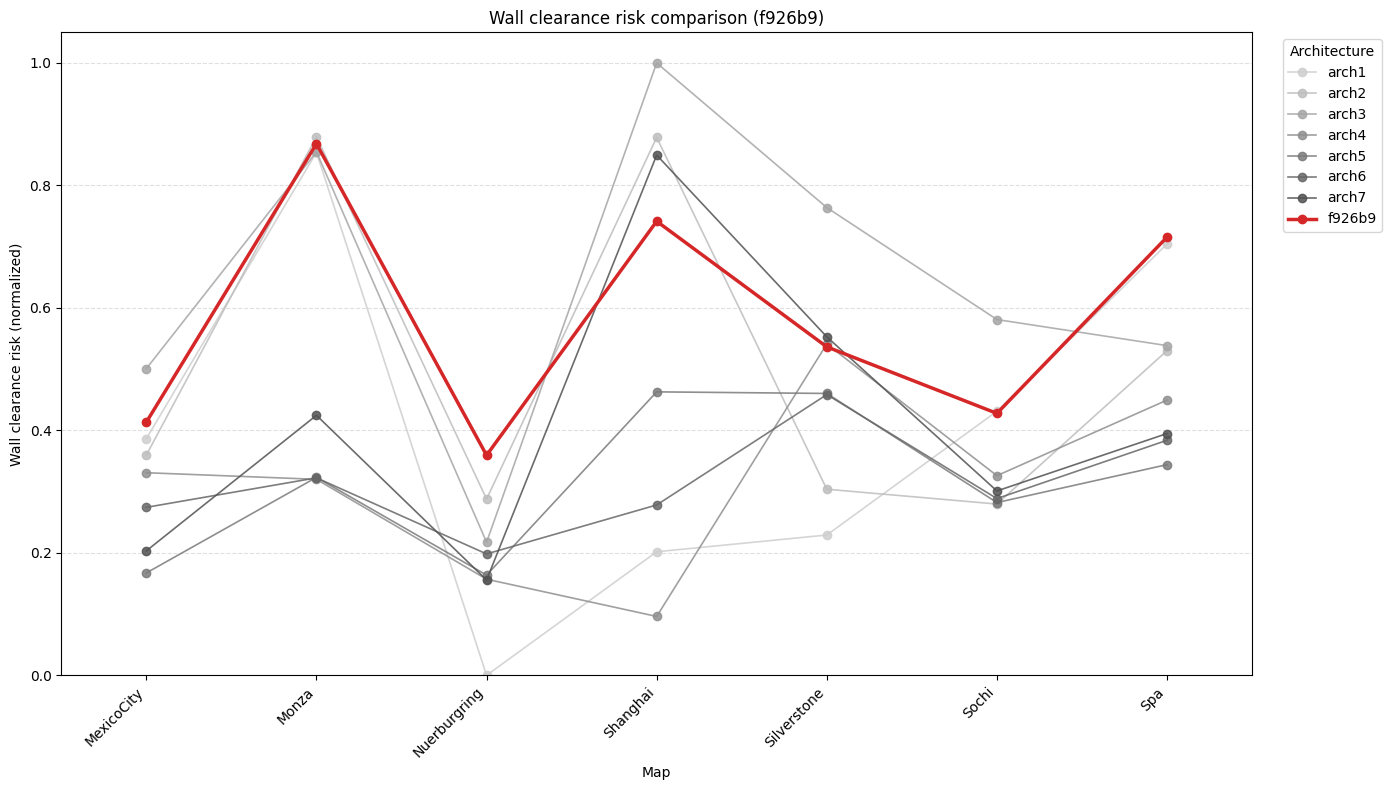

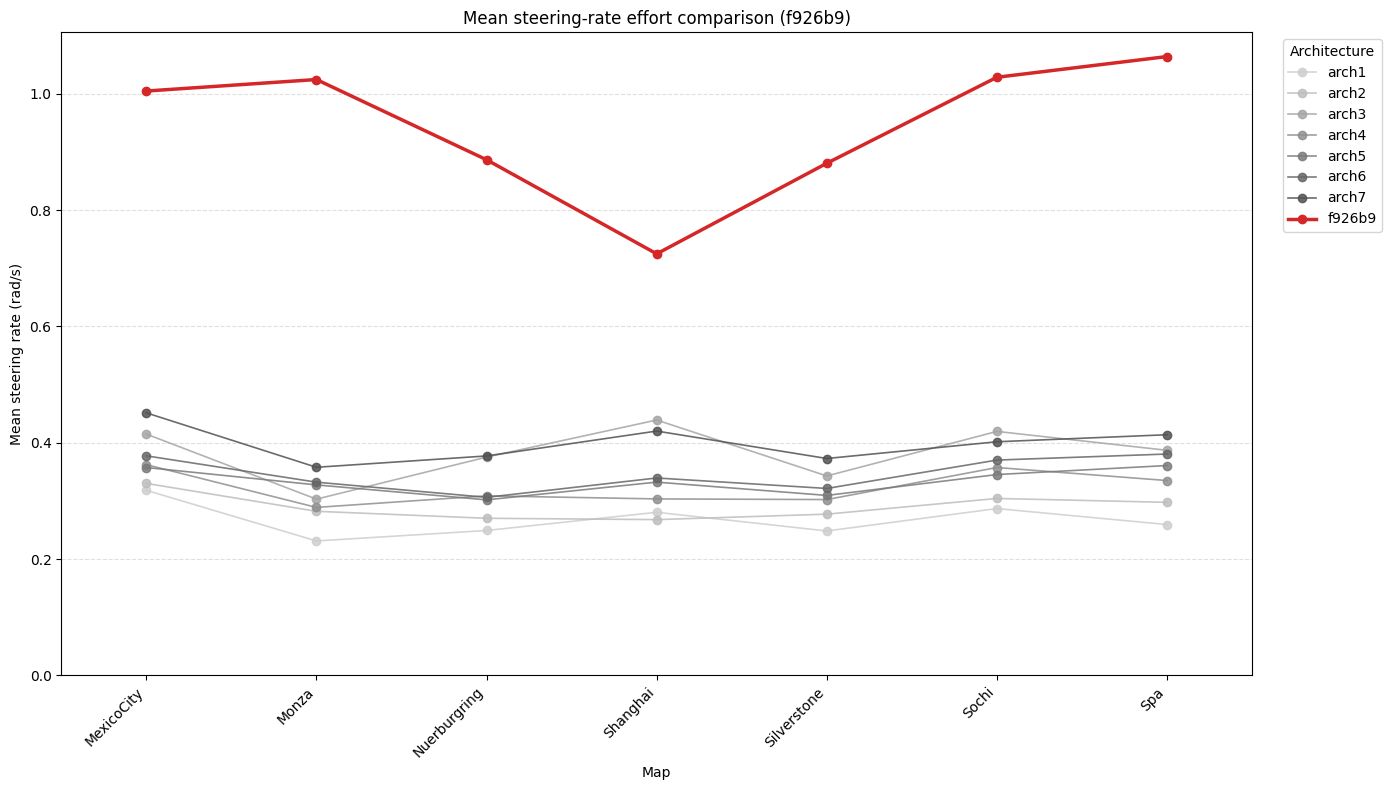

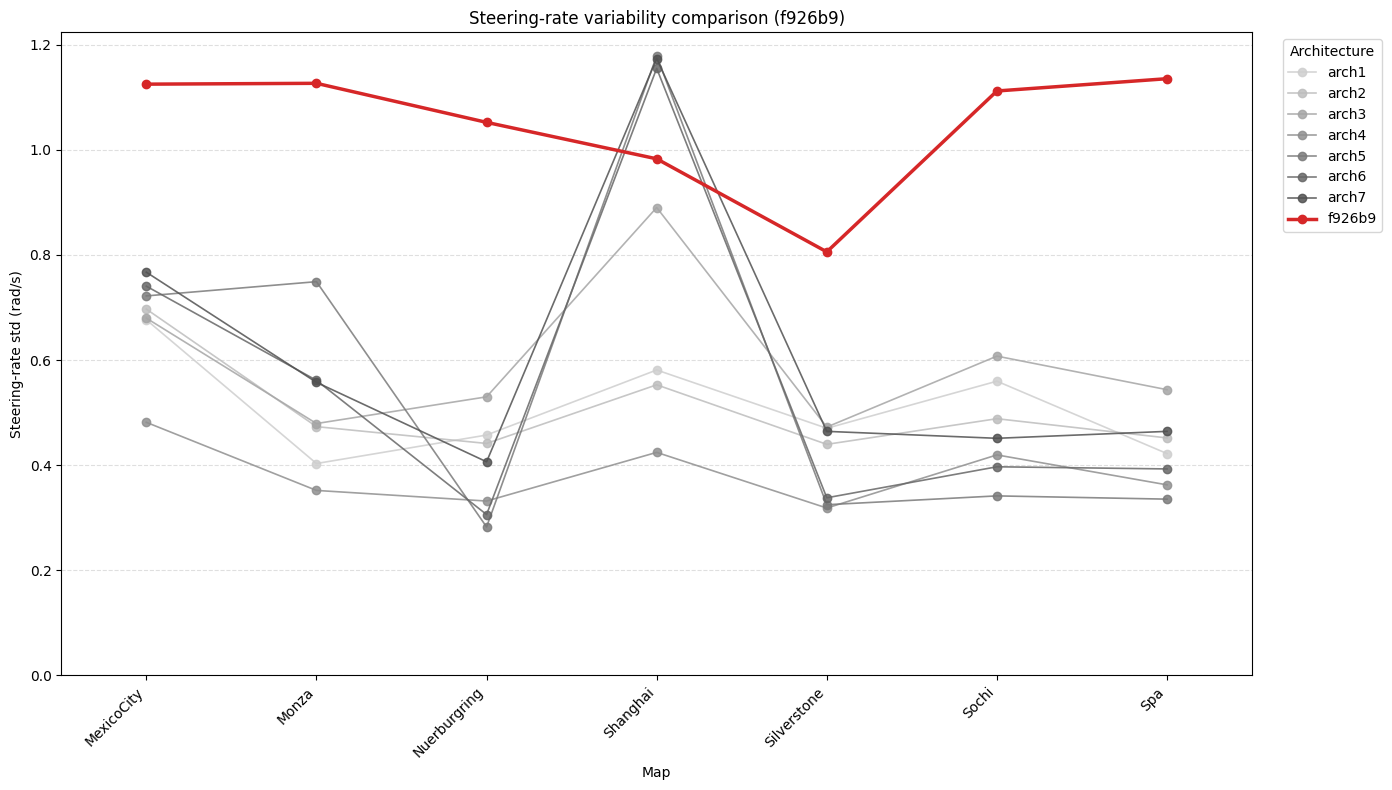

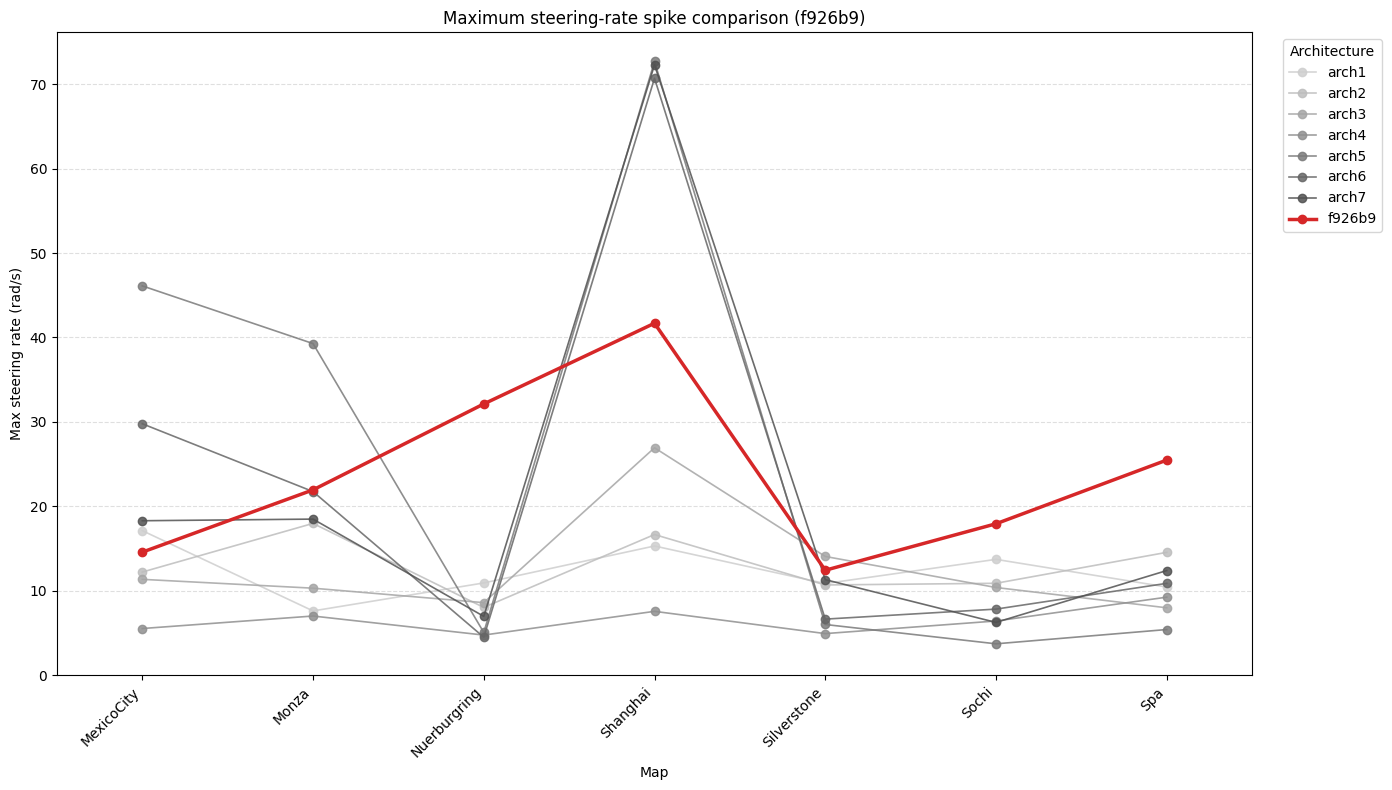

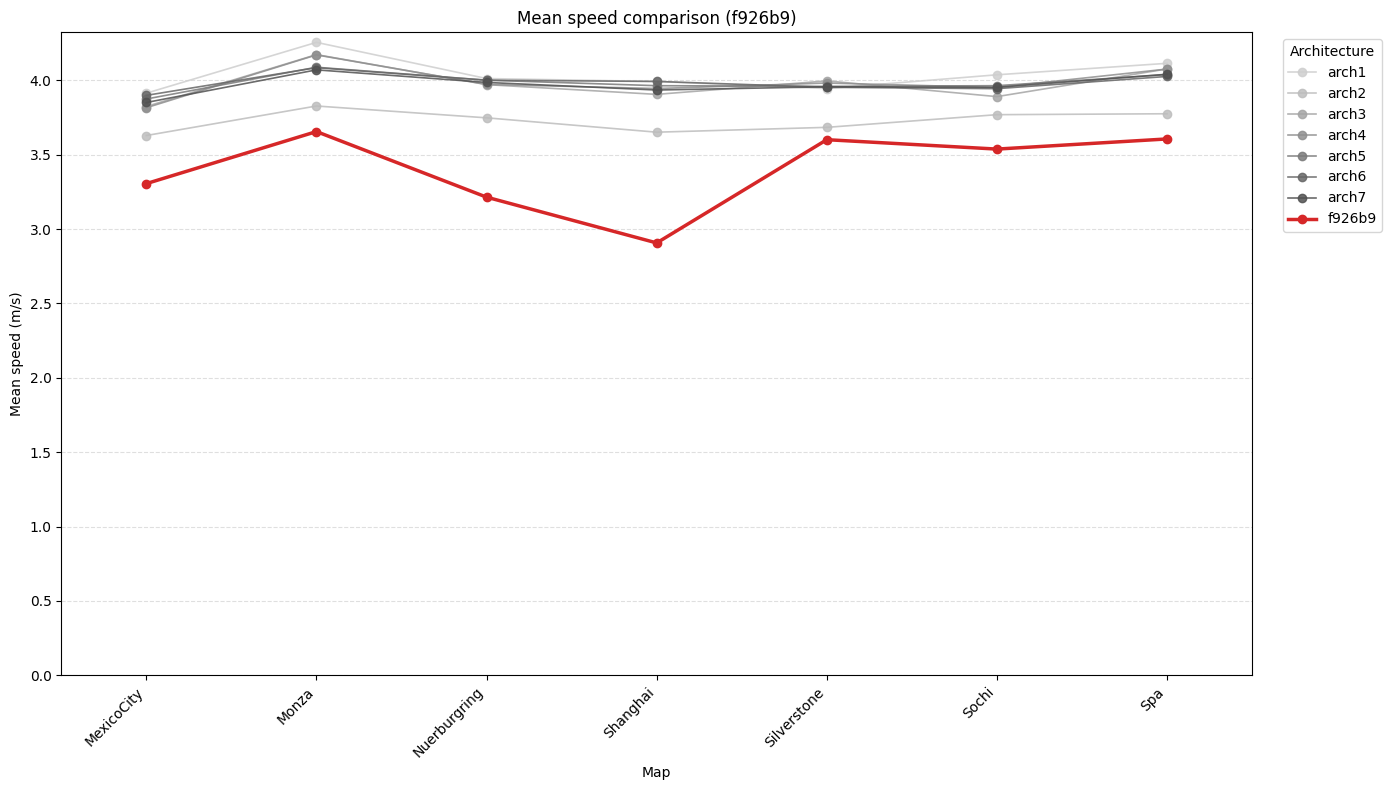

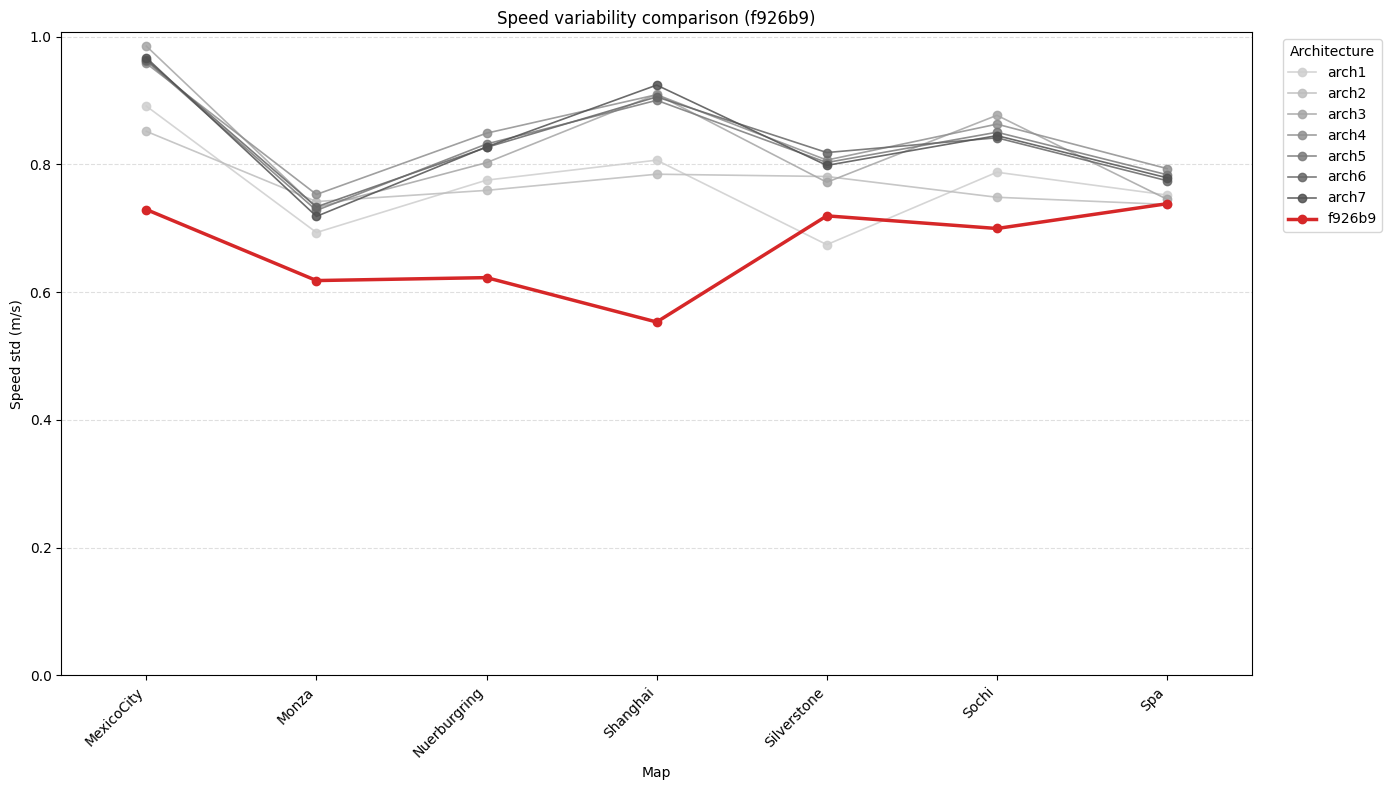

In [32]:
def plot_connected_metric(metric_pivot: pd.DataFrame, metric_key: str) -> None:
    spec = metric_specs[metric_key]
    maps = list(metric_pivot.columns)
    x_positions = range(len(maps))
    highlight_arch = HIGHLIGHT_ARCH
    has_highlight = highlight_arch in metric_pivot.index

    fig, ax = plt.subplots(figsize=(14, 8))
    other_arches = [
        arch for arch in metric_pivot.index
        if not (has_highlight and arch == highlight_arch)
    ]
    if other_arches:
        muted_scale = np.linspace(0.3, 0.75, len(other_arches))
        for scale, arch in zip(muted_scale, other_arches):
            ax.plot(
                x_positions,
                metric_pivot.loc[arch].values,
                marker="o",
                linewidth=1.2,
                color=plt.cm.Greys(scale),
                alpha=0.85,
                label=arch,
            )
    if has_highlight:
        ax.plot(
            x_positions,
            metric_pivot.loc[highlight_arch].values,
            marker="o",
            linewidth=2.5,
            color="#d62728",
            label=highlight_arch,
        )

    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(maps, rotation=45, ha="right")
    ax.set_xlim(-0.5, len(maps) - 0.5)
    ax.set_ylabel(spec["ylabel"])
    ax.set_xlabel("Map")
    ax.set_title(f"{spec['title']} comparison ({RUN_DIR.name})")
    ax.set_ylim(bottom=spec.get("ylim_bottom", 0.0))
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)
    ax.legend(title="Architecture", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

for metric_key, metric_pivot in metric_pivots.items():
    plot_connected_metric(metric_pivot, metric_key)


## Trajectory Progress Profiles

Each plot converts the 2D trajectory into cumulative path distance, then shows how `x` and `y` evolve along that distance. The waypoint centerline is shown as a dashed reference.


In [33]:
from f110_planning.utils.waypoint_utils import load_waypoints


PROGRESS_FRACTION = 0.1
show = False


def cumulative_path_distance(points: np.ndarray) -> np.ndarray:
    if len(points) == 0:
        return np.array([], dtype=float)
    deltas = np.diff(points[:, :2], axis=0)
    step_dist = np.linalg.norm(deltas, axis=1)
    return np.concatenate([[0.0], np.cumsum(step_dist)])


def first_progress_fraction(points: np.ndarray, fraction: float = PROGRESS_FRACTION) -> tuple[np.ndarray, np.ndarray]:
    s = cumulative_path_distance(points)
    if len(s) == 0:
        return s, points
    cutoff = s[-1] * fraction
    keep = s <= cutoff
    if not keep.any():
        keep[0] = True
    return s[keep], points[keep]


def plot_progress_profile(record: dict, run_dir: Path = RUN_DIR) -> None:
    trace_file = record.get("trace_file")
    if not trace_file:
        print(f"[warn] {record['map']} has no trace file; skipping")
        return

    trace_path = run_dir / trace_file
    if not trace_path.exists():
        print(f"[warn] missing trace file {trace_path}; skipping")
        return

    waypoints = load_waypoints(record["waypoints"])
    waypoint_s, waypoint_points = first_progress_fraction(waypoints)
    map_label = display_map_name(record["map"])
    highlight_arch = HIGHLIGHT_ARCH

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    with np.load(trace_path) as traces:
        other_runs = [
            run for run in record["runs"]
            if not (highlight_arch and run["label"] == highlight_arch)
        ]
        muted_scale = np.linspace(0.3, 0.75, max(len(other_runs), 1))

        for scale, run in zip(muted_scale, other_runs):
            key = f"{run['label']}_positions"
            if key not in traces:
                continue
            points = traces[key]
            s, segment = first_progress_fraction(points)
            color = plt.cm.Greys(scale)
            axes[0].plot(s, segment[:, 0], color=color, linewidth=1.0, alpha=0.8, label=run["label"])
            axes[1].plot(s, segment[:, 1], color=color, linewidth=1.0, alpha=0.8, label=run["label"])

        if highlight_arch:
            key = f"{highlight_arch}_positions"
            if key in traces:
                points = traces[key]
                s, segment = first_progress_fraction(points)
                axes[0].plot(s, segment[:, 0], color="#d62728", linewidth=2.4, label=highlight_arch)
                axes[1].plot(s, segment[:, 1], color="#d62728", linewidth=2.4, label=highlight_arch)

    axes[0].plot(waypoint_s, waypoint_points[:, 0], color="#1f77b4", linestyle="--", linewidth=1.6, label="waypoint")
    axes[1].plot(waypoint_s, waypoint_points[:, 1], color="#1f77b4", linestyle="--", linewidth=1.6, label="waypoint")

    axes[0].set_ylabel("x position (m)")
    axes[1].set_ylabel("y position (m)")
    axes[1].set_xlabel("Cumulative path distance (m)")
    axes[0].set_title(f"First {PROGRESS_FRACTION:.0%} trajectory progress | {map_label} ({RUN_DIR.name})")
    for ax in axes:
        ax.grid(True, axis="both", linestyle="--", alpha=0.35)
        ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

if show:
    for record in METRIC_RECORDS:
        plot_progress_profile(record)


## Cross-Run Metric Scatter

Each x-axis position is a compare run directory. For each run, the dots show the selected metric aggregated across evaluation maps for arch1-7 and the run-specific candidate model, displayed as arch8.


Compare runs: 193215, be986b, f926b9


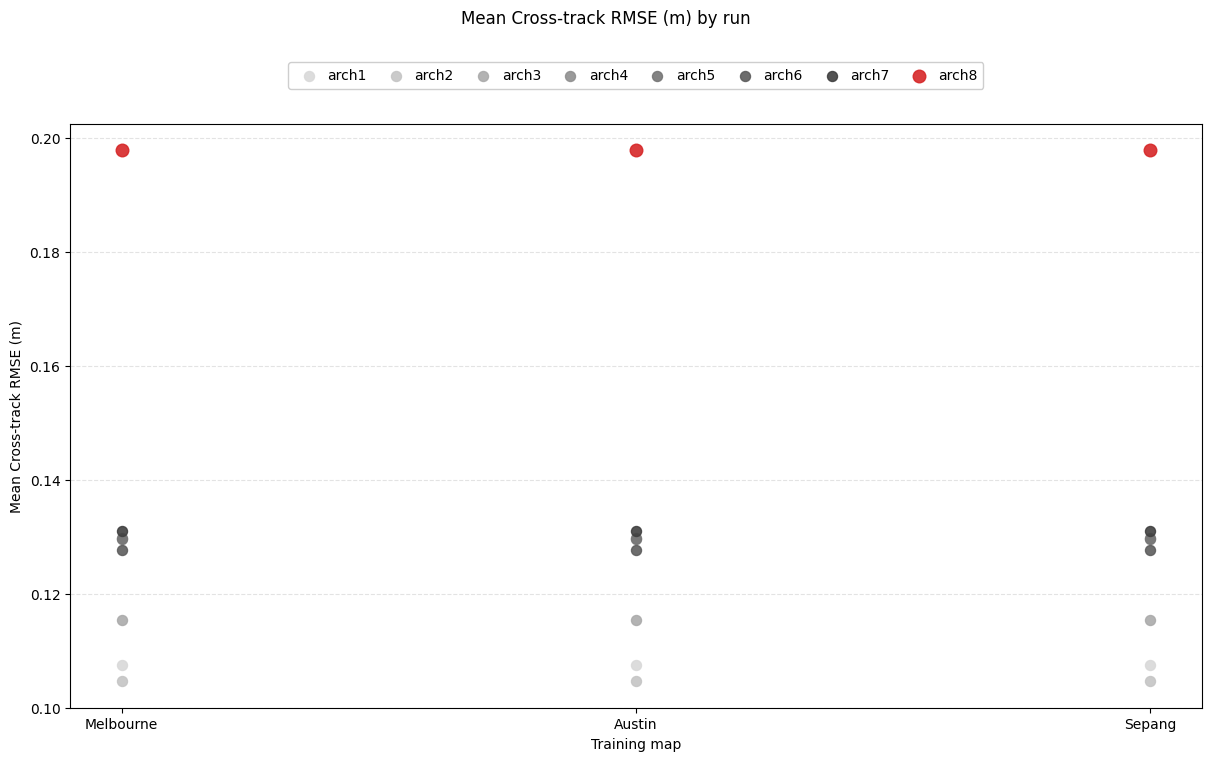

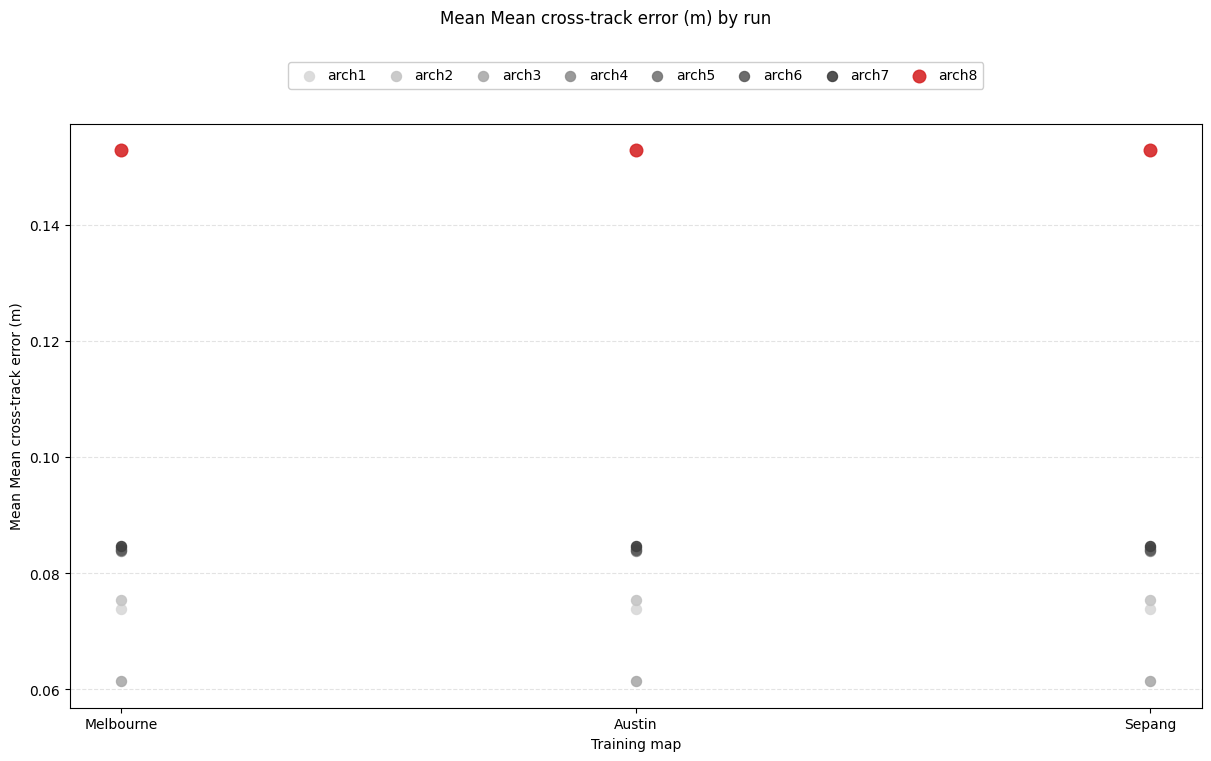

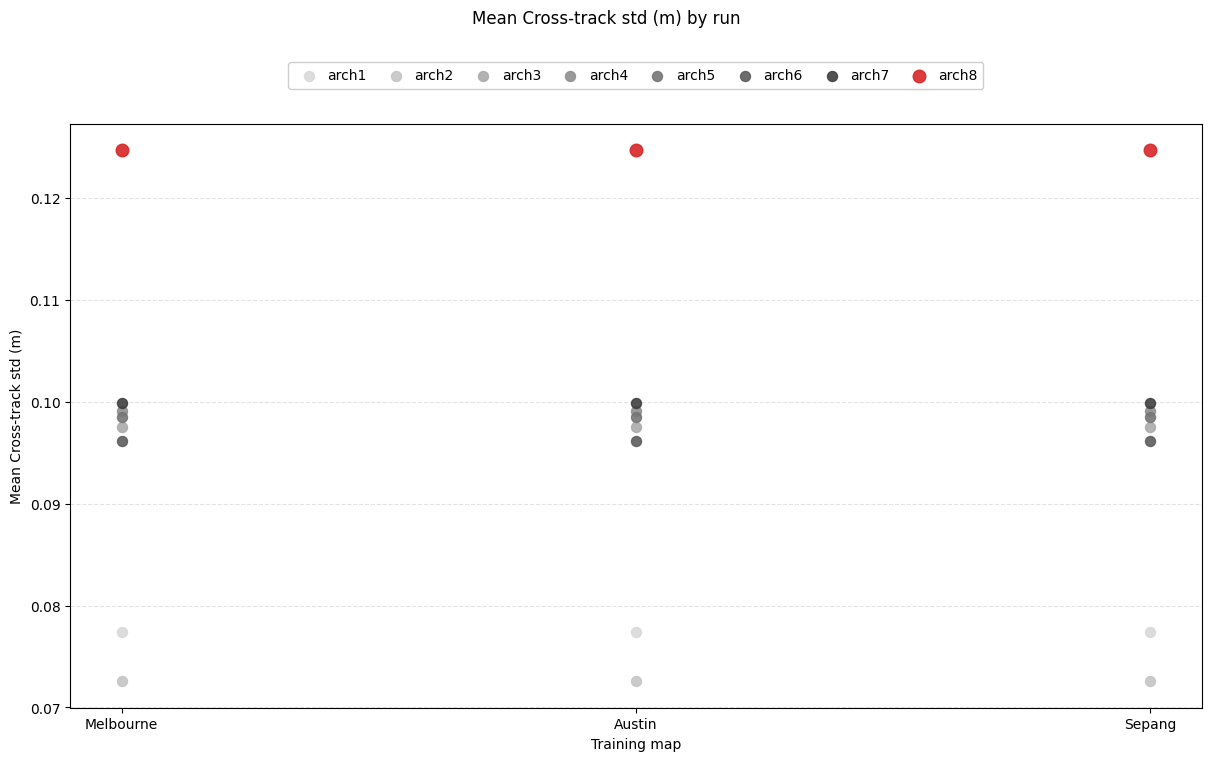

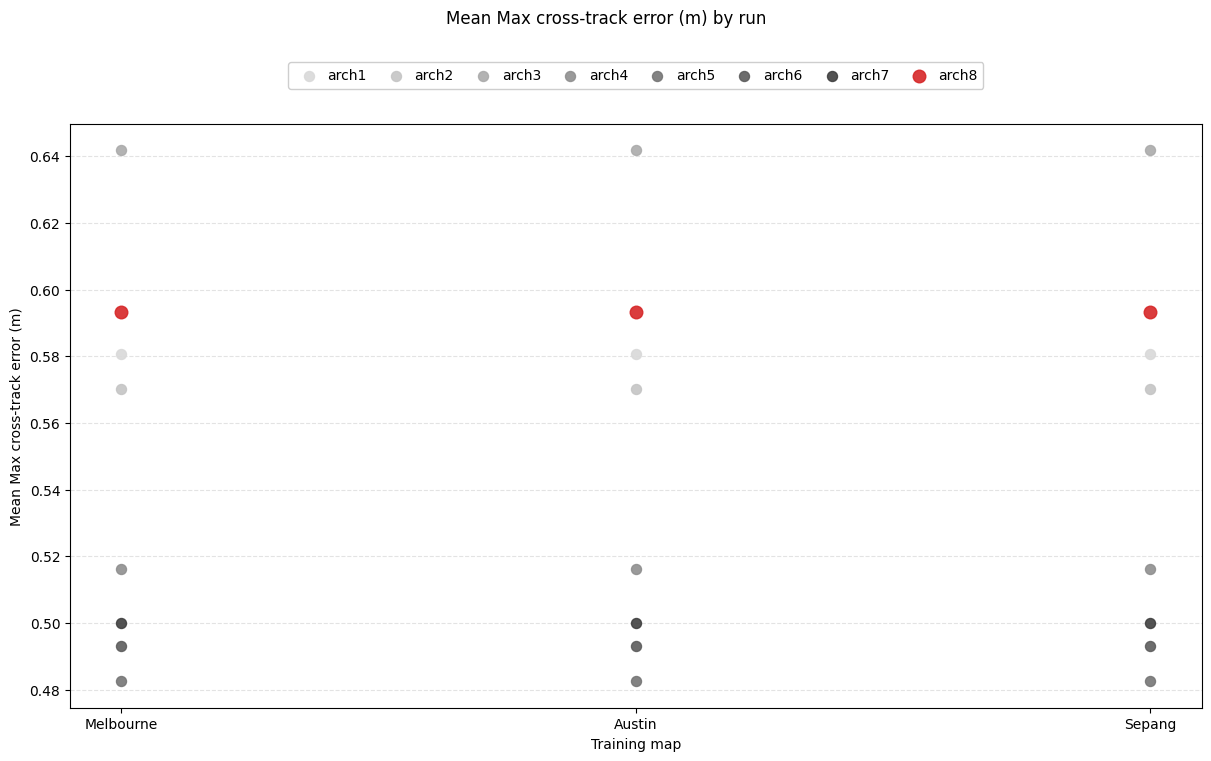

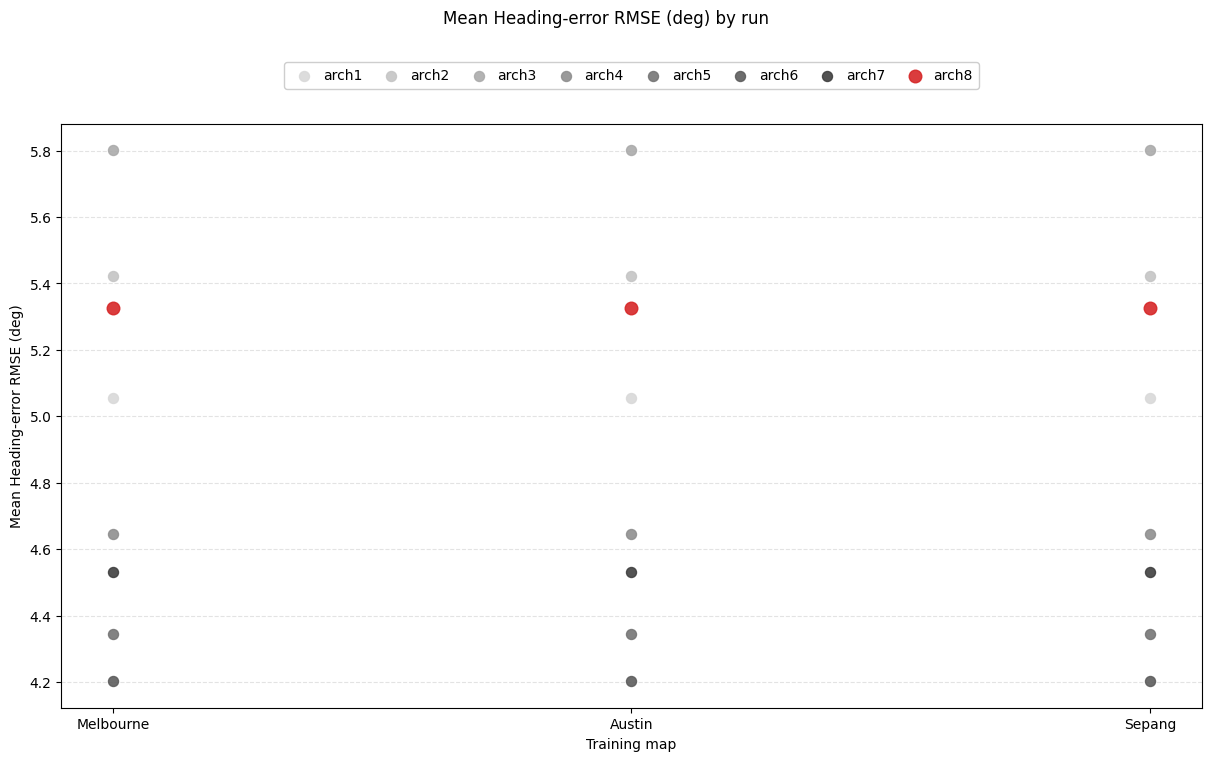

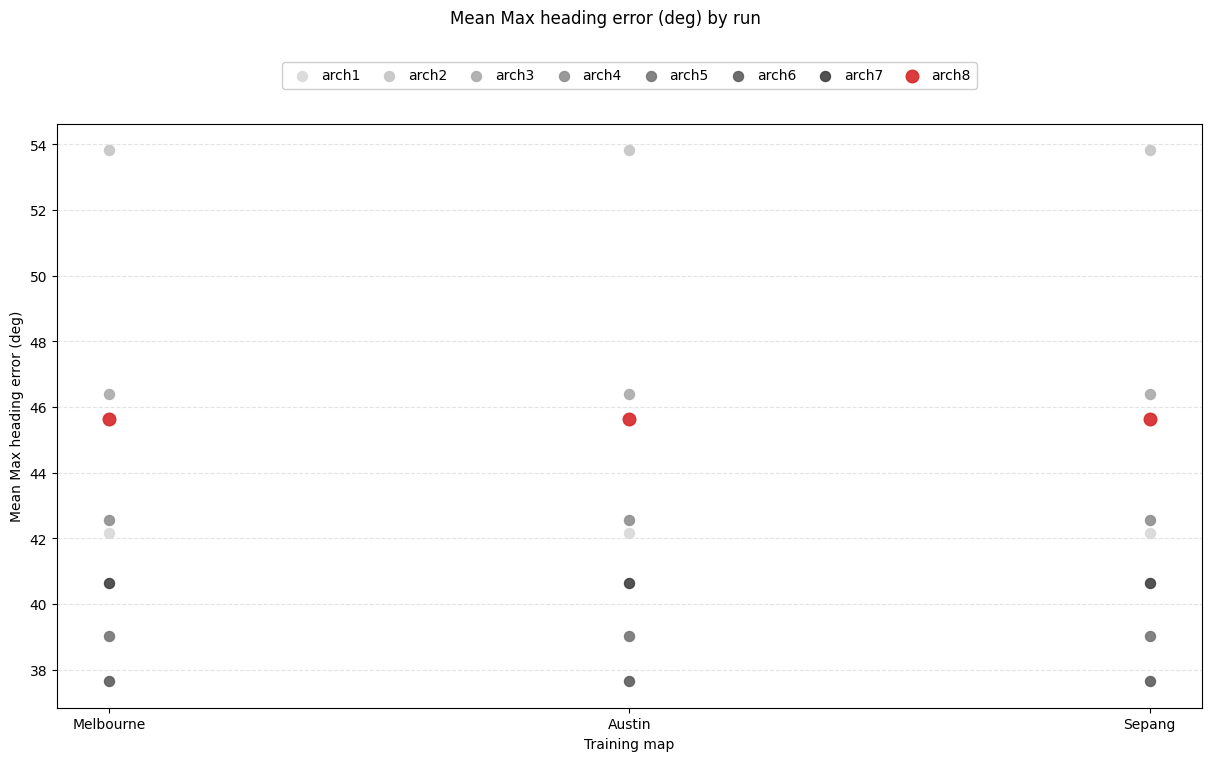

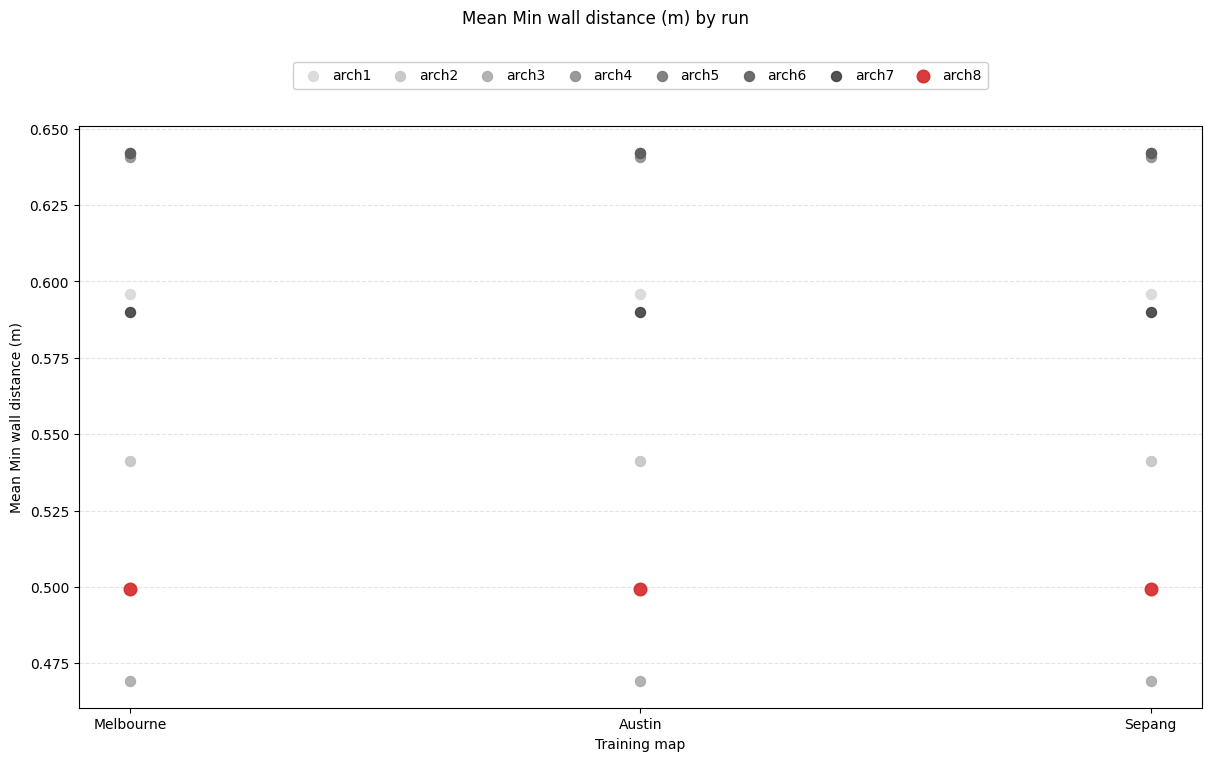

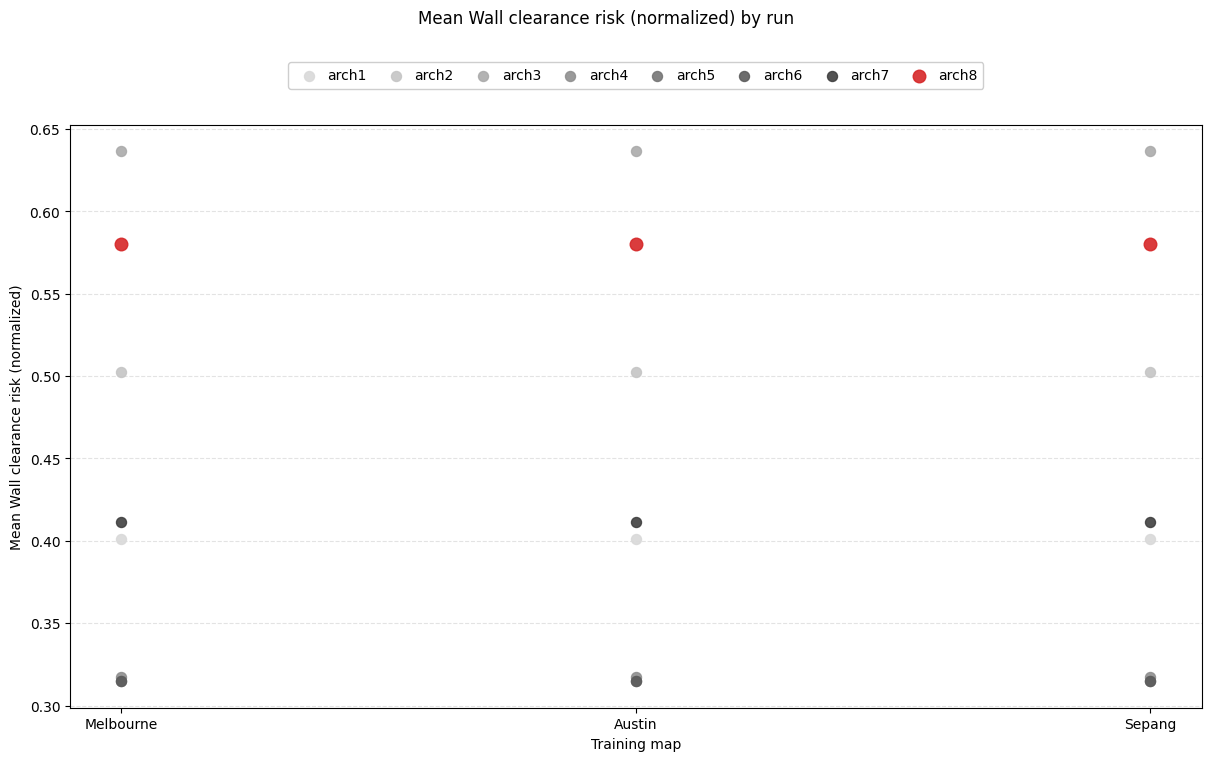

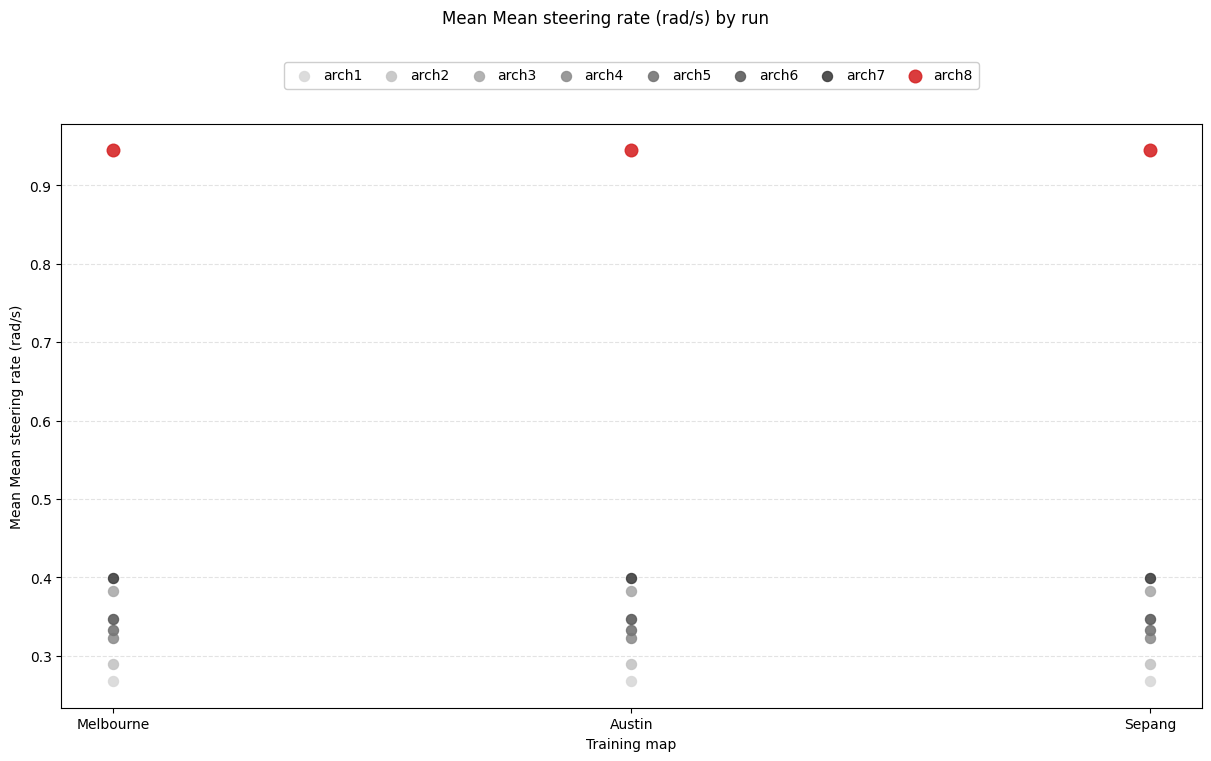

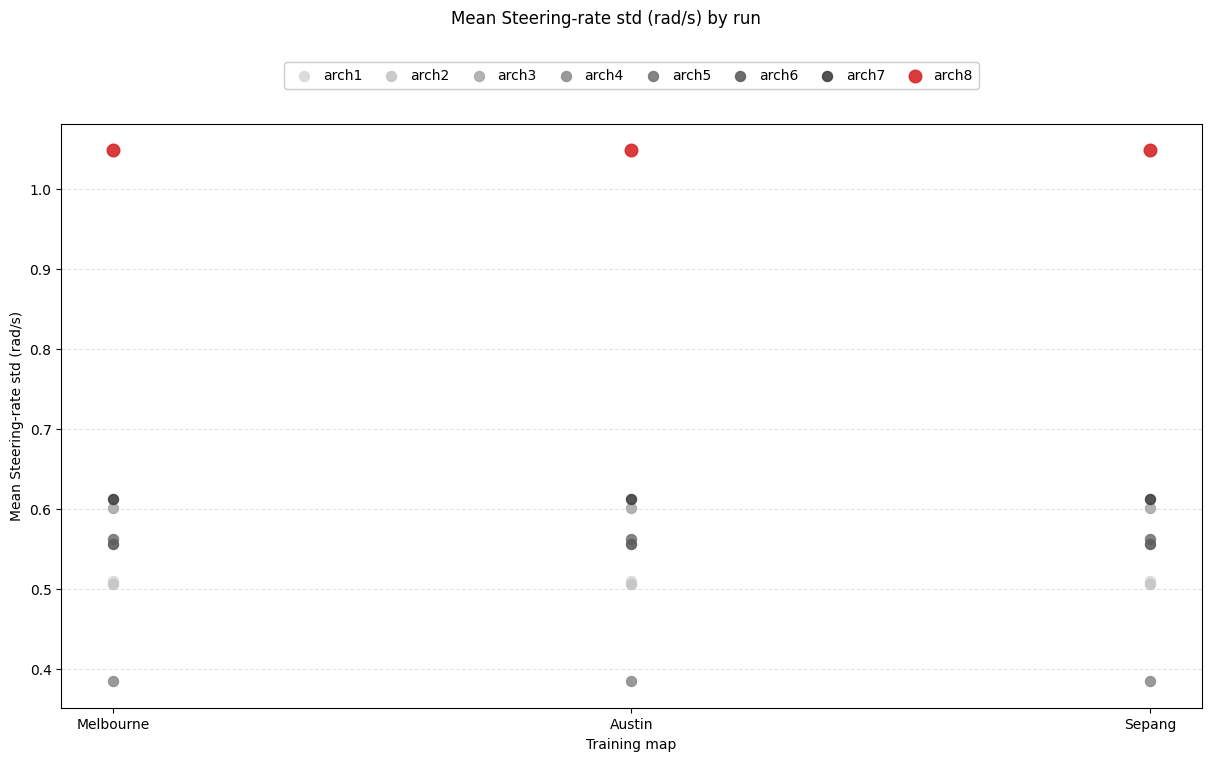

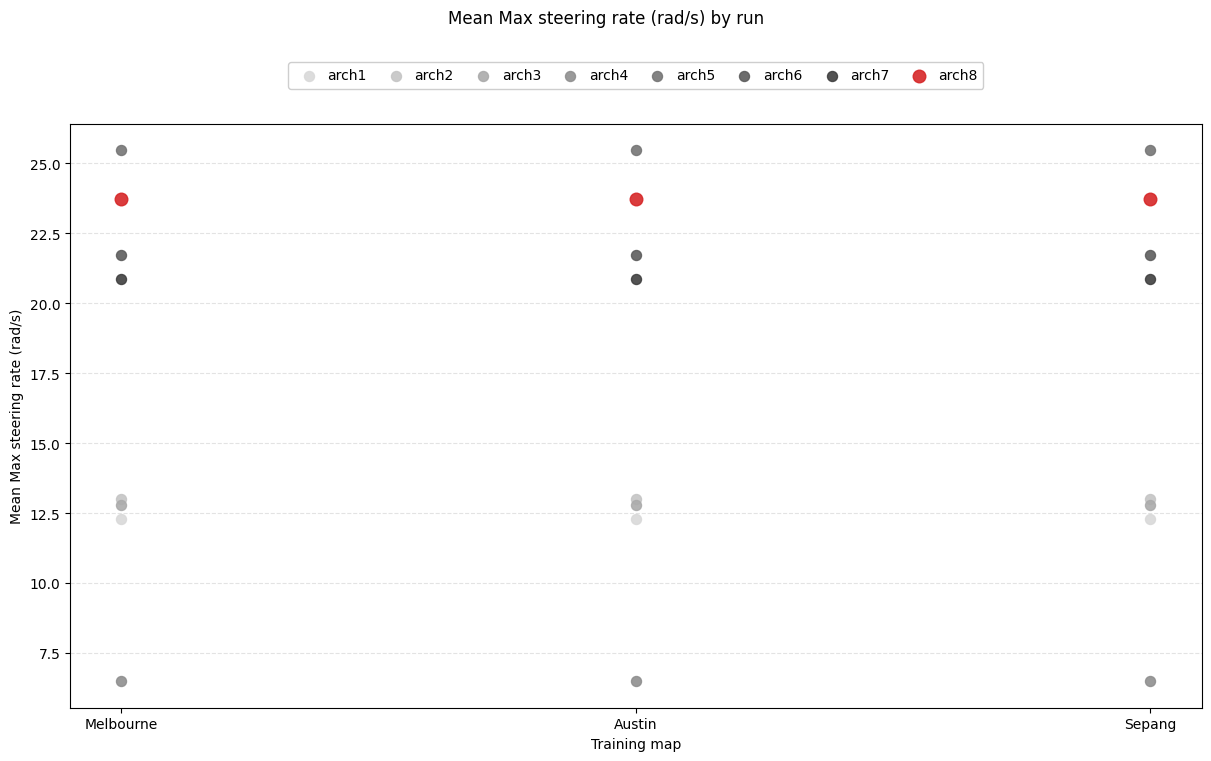

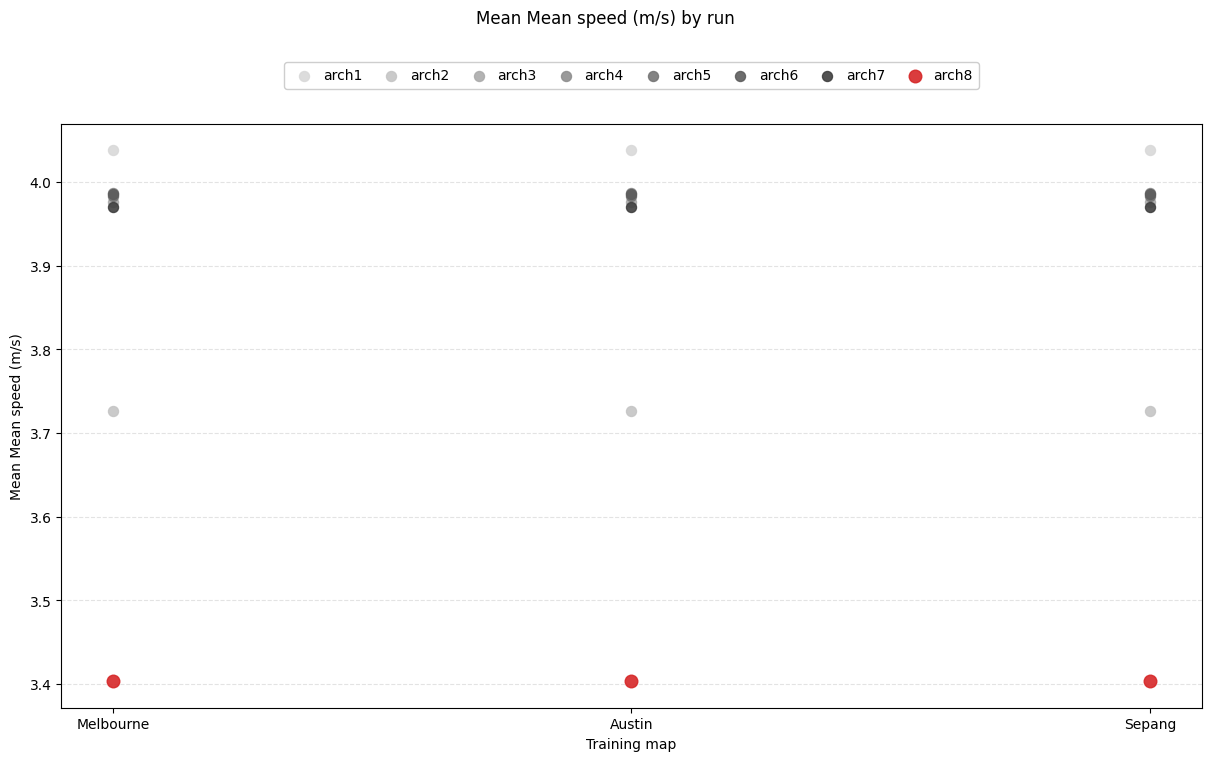

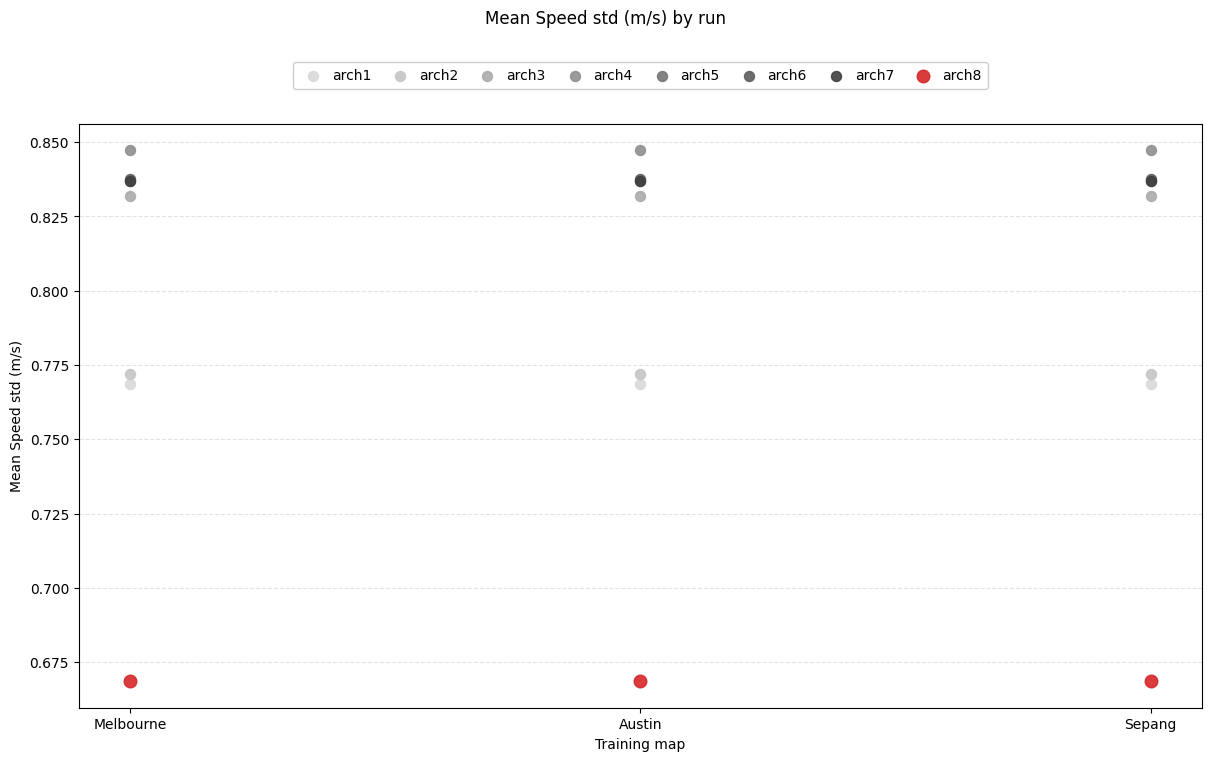

In [34]:
EXCLUDE_COMPARE_RUN_IDS = set()
TRAINED_MAP_LABELS = {
    "193215": "Melbourne",
    "be986b": "Austin",
    "f926b9": "Sepang",
    "017f7c": "Yas Marina",
    "08e72b": "Moscow Raceway",
    "1b391f": "Sakhir",
    "3cd867": "Budapest",
}


def discover_compare_run_dirs(base_dir: Path = BASE_OUTPUT_DIR) -> list[Path]:
    run_dirs = sorted(
        path.parent
        for path in base_dir.glob("*/metrics.jsonl")
        if path.parent.name not in EXCLUDE_COMPARE_RUN_IDS
    )
    if not run_dirs:
        raise FileNotFoundError(f"No metrics.jsonl run directories found under {base_dir}")
    return run_dirs


COMPARE_RUN_DIRS = discover_compare_run_dirs()
print("Compare runs:", ", ".join(path.name for path in COMPARE_RUN_DIRS))
CROSS_RUN_AGG = "mean"


def resolve_compare_run_dir(path_like: str | Path) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = BASE_OUTPUT_DIR / path
    if path.is_file():
        path = path.parent
    metrics_path = path / "metrics.jsonl"
    if not metrics_path.exists():
        raise FileNotFoundError(f"{metrics_path} does not exist")
    return path


def load_run_metric_rows(run_dir: Path, metric_key: str) -> pd.DataFrame:
    source_metric = "wall_min_distance_m" if metric_key == "wall_min_distance_risk" else metric_key
    metrics_path = run_dir / "metrics.jsonl"
    rows: list[dict[str, object]] = []
    with metrics_path.open("r", encoding="utf-8") as fh:
        records = [json.loads(line) for line in fh if line.strip()]

    for record in records:
        for run in record["runs"]:
            raw_label = run["label"]
            arch_label = "arch8" if raw_label == run_dir.name else raw_label
            rows.append(
                {
                    "run_dir": run_dir.name,
                    "map": record["map"],
                    "map_label": display_map_name(record["map"]),
                    "arch": arch_label,
                    "raw_label": raw_label,
                    "value": run.get(source_metric),
                }
            )
    return pd.DataFrame(rows)


def apply_derived_metric_transform(metric_df: pd.DataFrame, metric_key: str) -> pd.DataFrame:
    if metric_key != "wall_min_distance_risk":
        return metric_df
    metric_df = metric_df.copy()
    span = metric_df["value"].max() - metric_df["value"].min()
    if span == 0:
        metric_df["value"] = 0.5
    else:
        metric_df["value"] = 1.0 - ((metric_df["value"] - metric_df["value"].min()) / span)
    return metric_df


def aggregate_cross_run_metric(run_dirs: list[str | Path], metric_key: str) -> pd.DataFrame:
    frames = [load_run_metric_rows(resolve_compare_run_dir(run_dir), metric_key) for run_dir in run_dirs]
    metric_df = pd.concat(frames, ignore_index=True)
    metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
    metric_df = metric_df.dropna(subset=["value"])
    metric_df = apply_derived_metric_transform(metric_df, metric_key)

    if CROSS_RUN_AGG == "mean":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].mean()
    if CROSS_RUN_AGG == "median":
        return metric_df.groupby(["run_dir", "arch"], as_index=False)["value"].median()
    raise ValueError(f"Unsupported CROSS_RUN_AGG={CROSS_RUN_AGG!r}")


def plot_cross_run_metric(run_dirs: list[str | Path], metric_key: str) -> None:
    agg = aggregate_cross_run_metric(run_dirs, metric_key)
    resolved_dirs = [resolve_compare_run_dir(run_dir) for run_dir in run_dirs]
    run_labels = [run_dir.name for run_dir in resolved_dirs]
    x_labels = [TRAINED_MAP_LABELS.get(run_dir.name, run_dir.name) for run_dir in resolved_dirs]
    x_lookup = {label: idx for idx, label in enumerate(run_labels)}
    arch_order = [f"arch{i}" for i in range(1, 9)]

    fig = plt.figure(figsize=(12, 7.5), constrained_layout=True)
    grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.12, 0.88])
    legend_ax = fig.add_subplot(grid[0])
    ax = fig.add_subplot(grid[1])
    legend_ax.axis("off")

    handles = []
    labels = []
    for arch in arch_order:
        arch_df = agg[agg["arch"] == arch]
        if arch_df.empty:
            continue
        xs = [x_lookup[row.run_dir] for row in arch_df.itertuples()]
        color = "#d62728" if arch == "arch8" else plt.cm.Greys(0.25 + 0.55 * (int(arch[4:]) - 1) / 6)
        size = 82 if arch == "arch8" else 52
        points = ax.scatter(
            xs,
            arch_df["value"],
            color=color,
            s=size,
            alpha=0.9,
            label=arch,
            zorder=3 if arch == "arch8" else 2,
        )
        handles.append(points)
        labels.append(arch)

    metric_label = metric_specs.get(metric_key, {}).get("ylabel", metric_key)
    ax.set_xticks(range(len(run_labels)))
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_ylabel(f"{CROSS_RUN_AGG.title()} {metric_label}")
    ax.set_xlabel("Training map")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    fig.suptitle(f"{CROSS_RUN_AGG.title()} {metric_label} by run")
    legend_ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),
        frameon=True,
        framealpha=0.95,
        handletextpad=0.35,
        columnspacing=1.1,
        borderpad=0.45,
    )
    plt.show()


for metric_key in metric_specs:
    plot_cross_run_metric(COMPARE_RUN_DIRS, metric_key)


## Cross-Run Metric Box Plots

Each x-axis group is a training map. For each architecture, the box-and-whisker plot summarizes that metric across the evaluation maps in the corresponding `metrics.jsonl`.


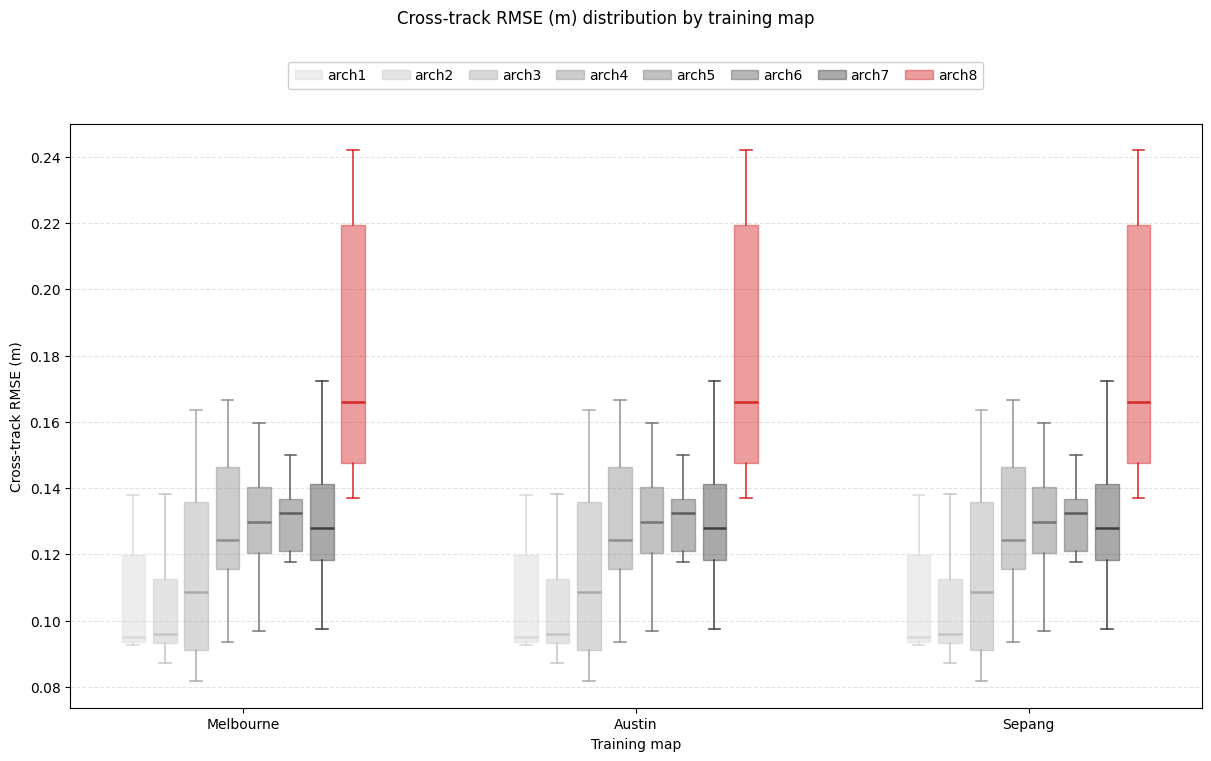

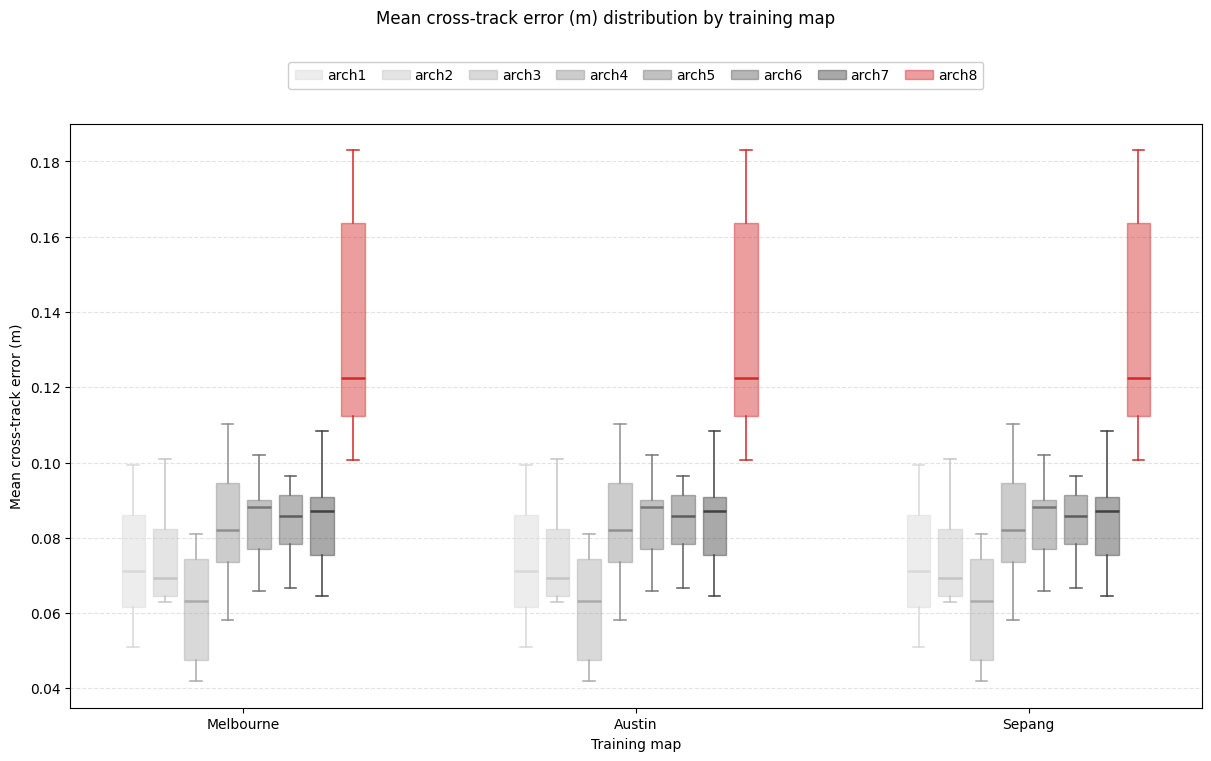

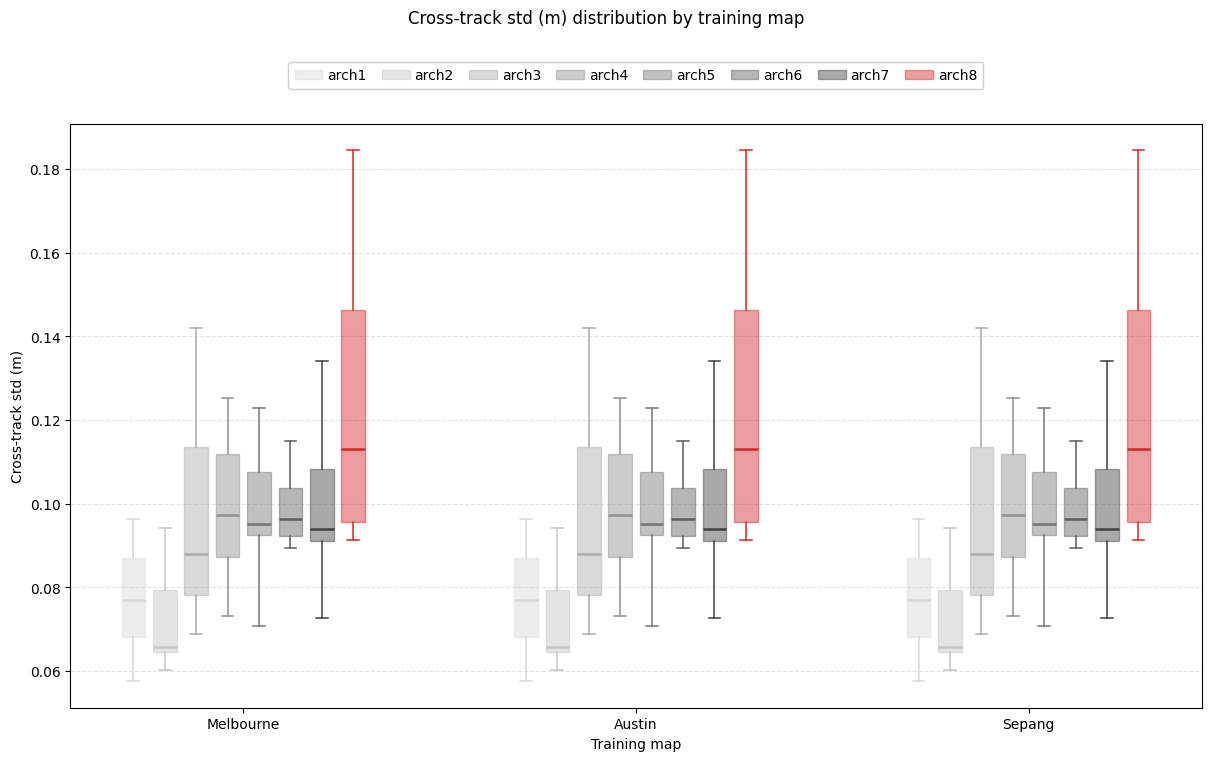

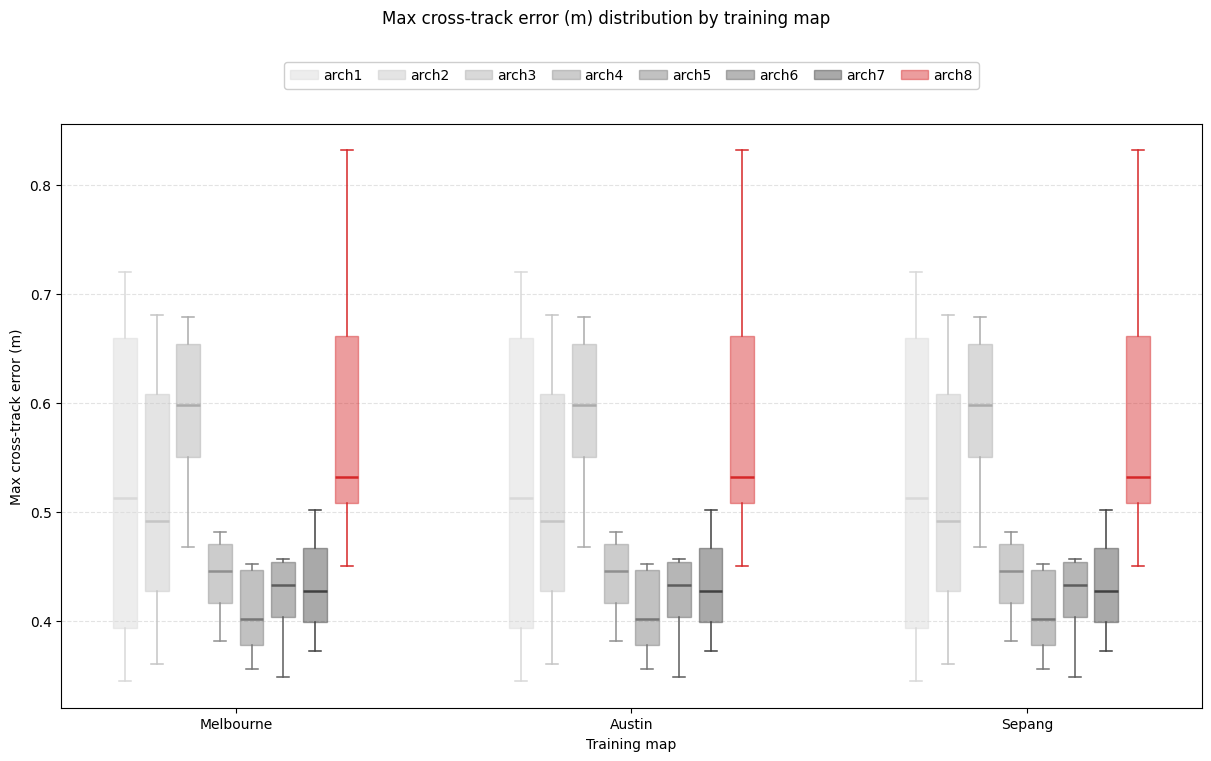

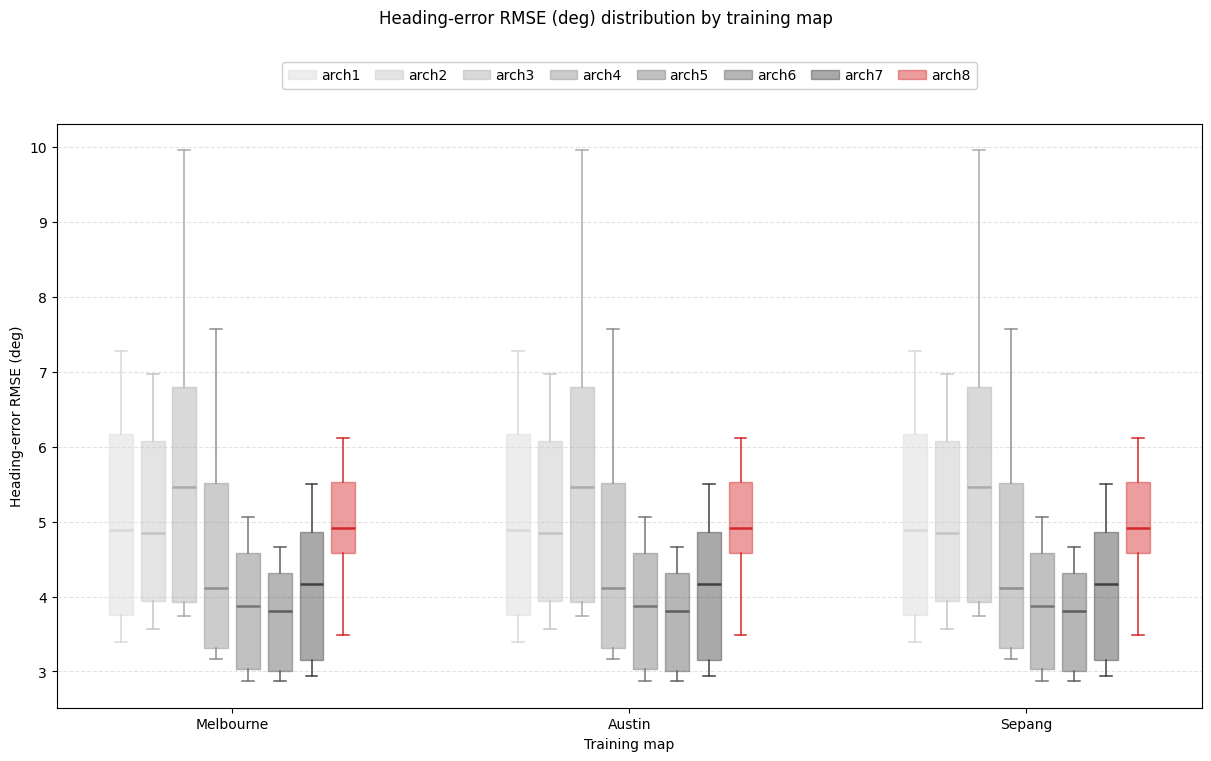

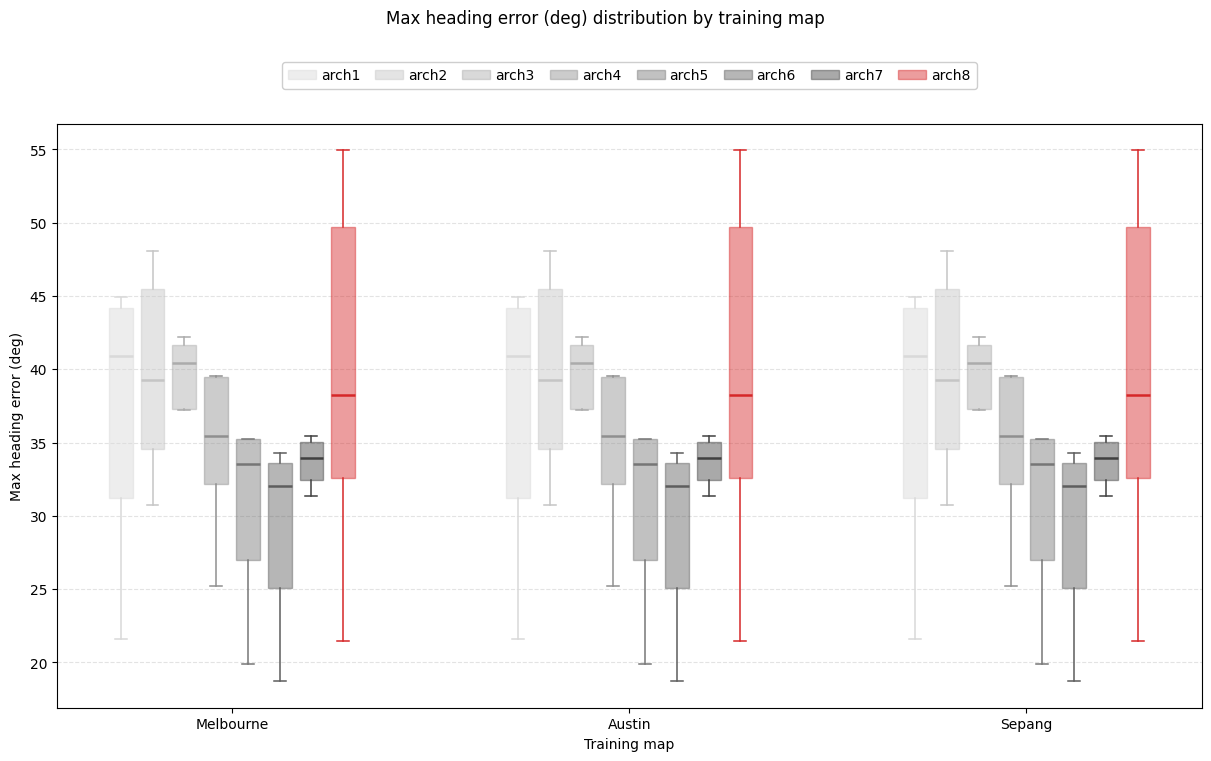

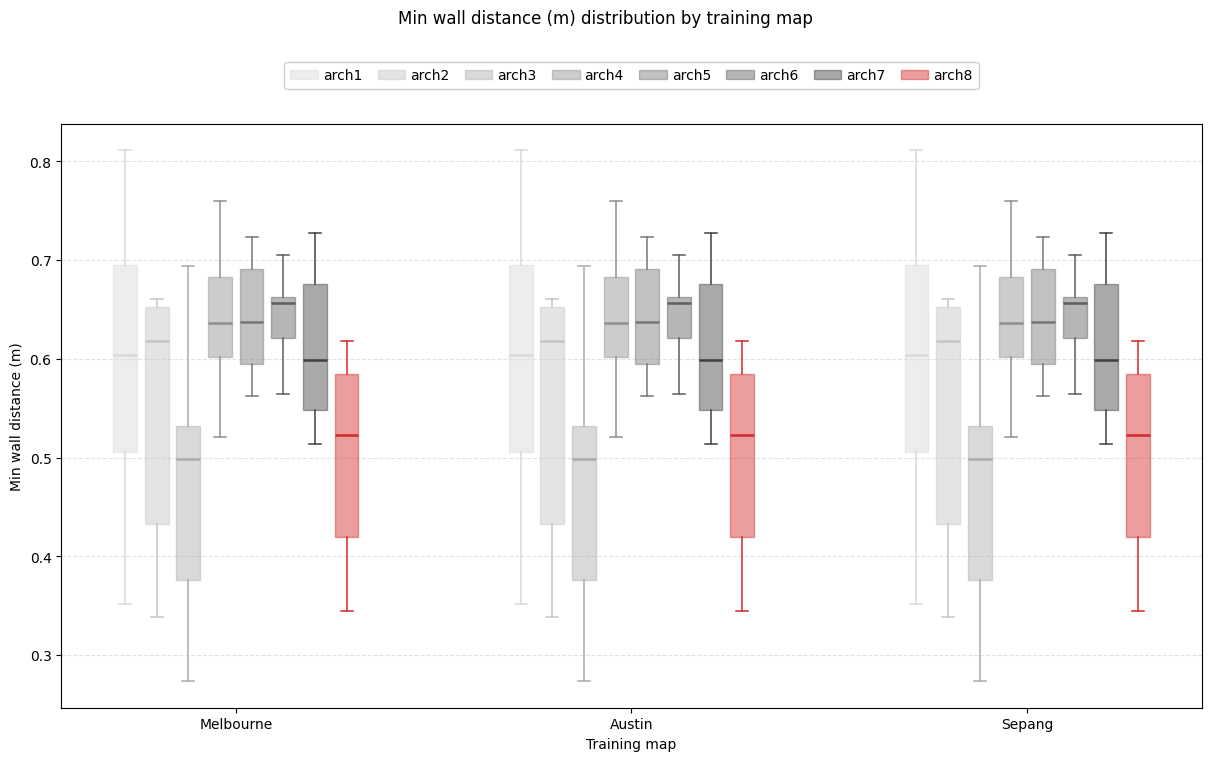

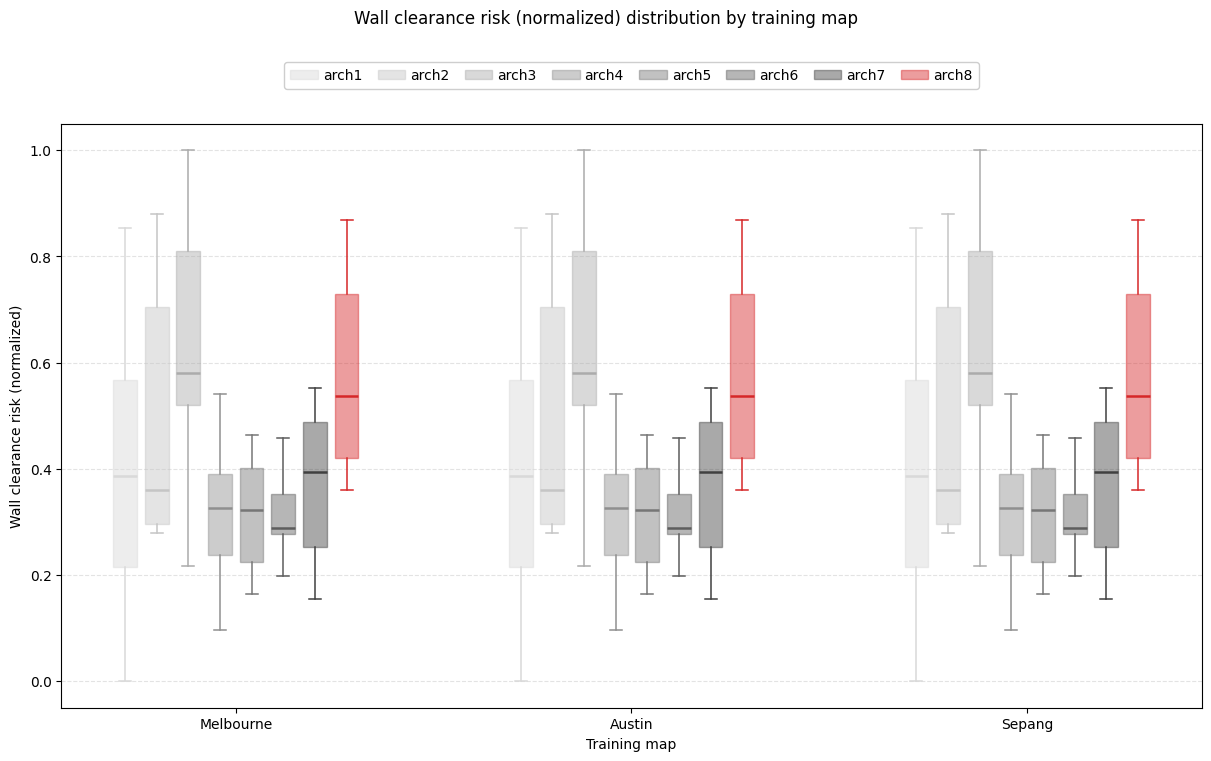

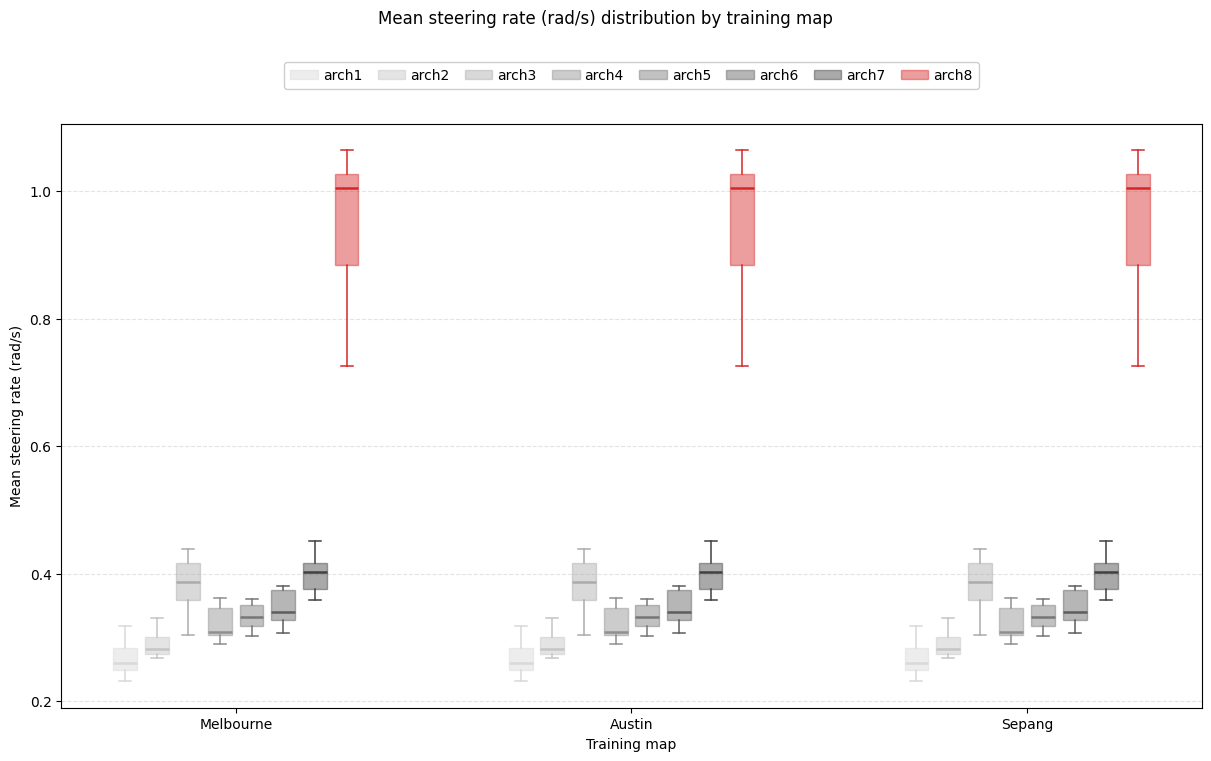

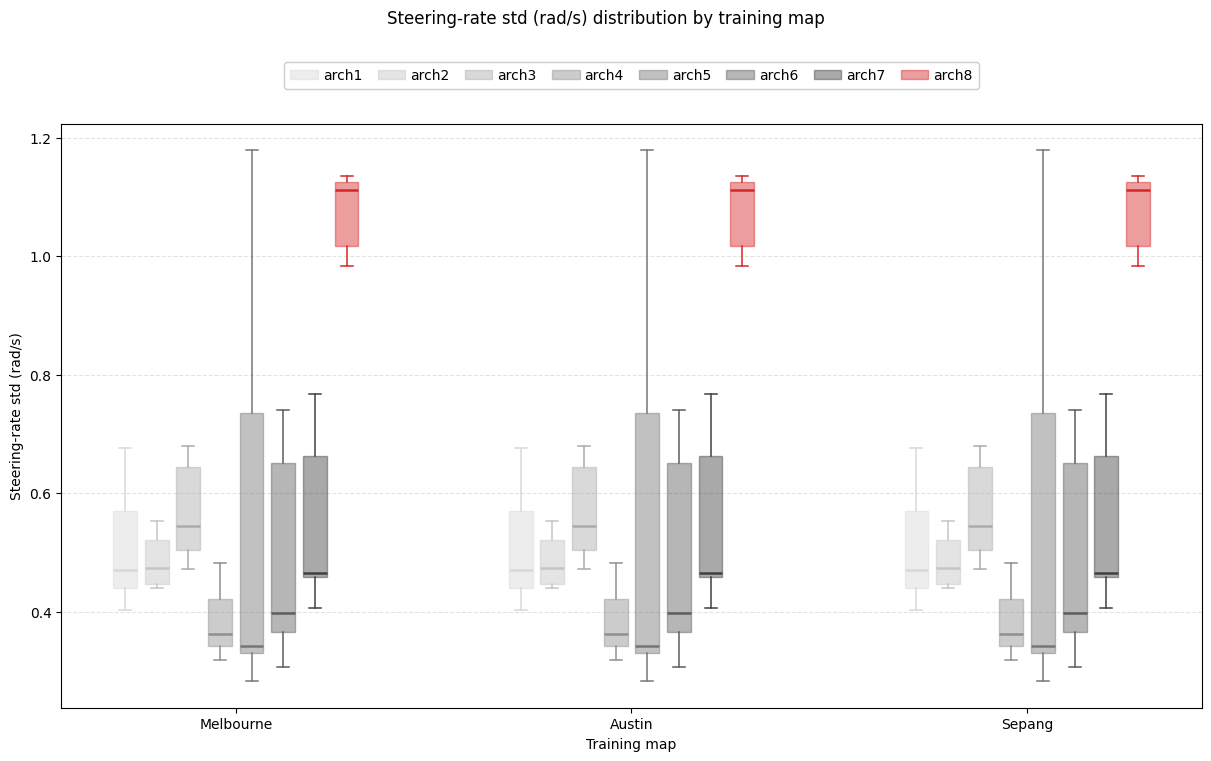

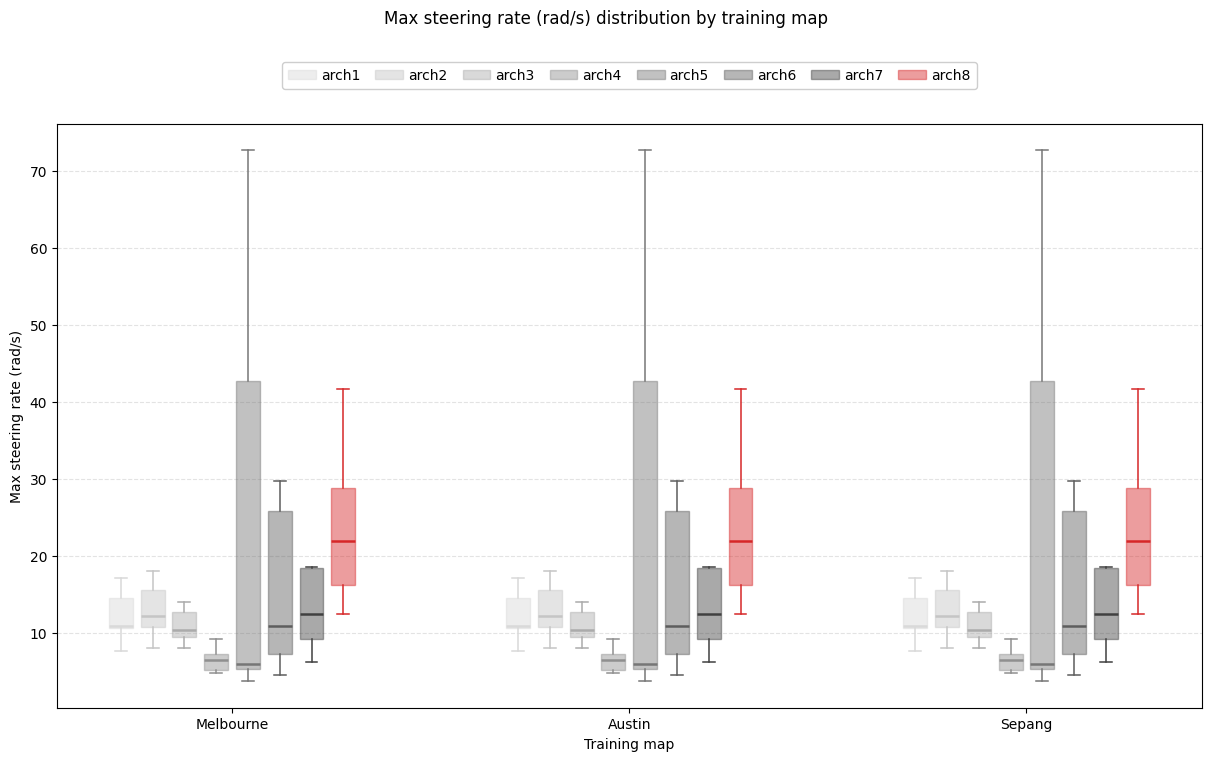

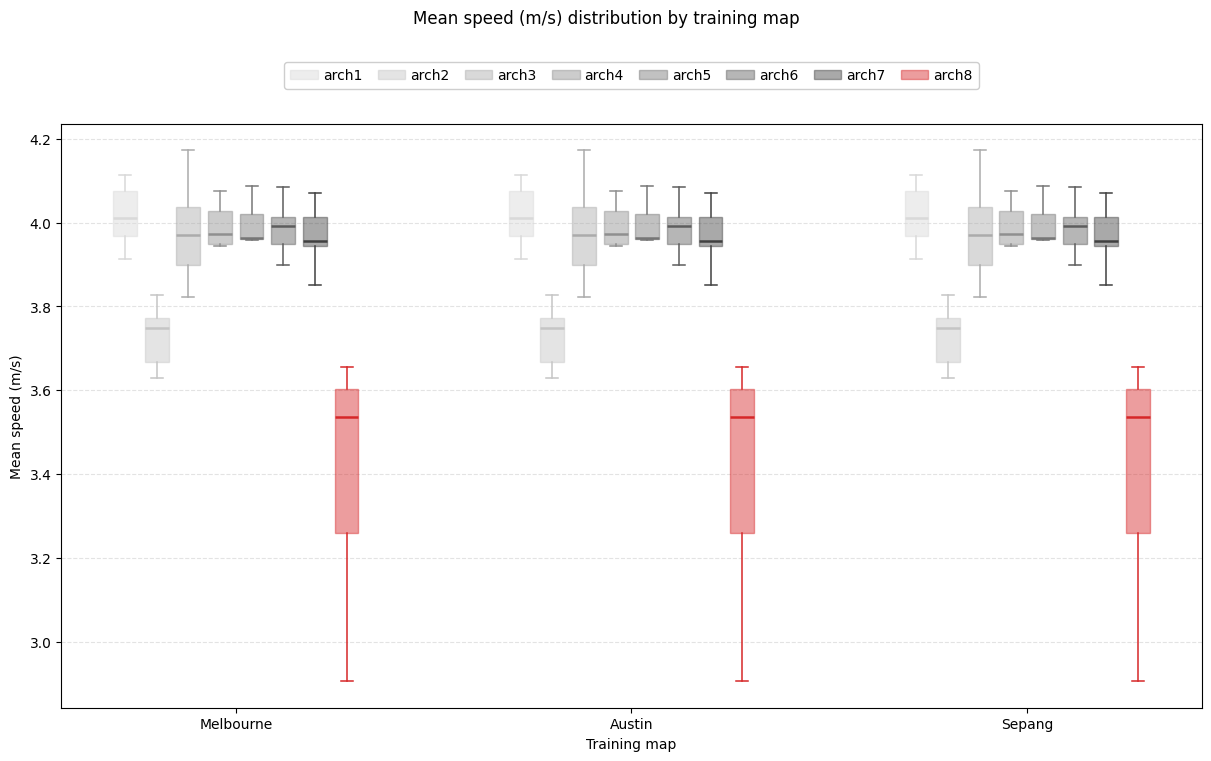

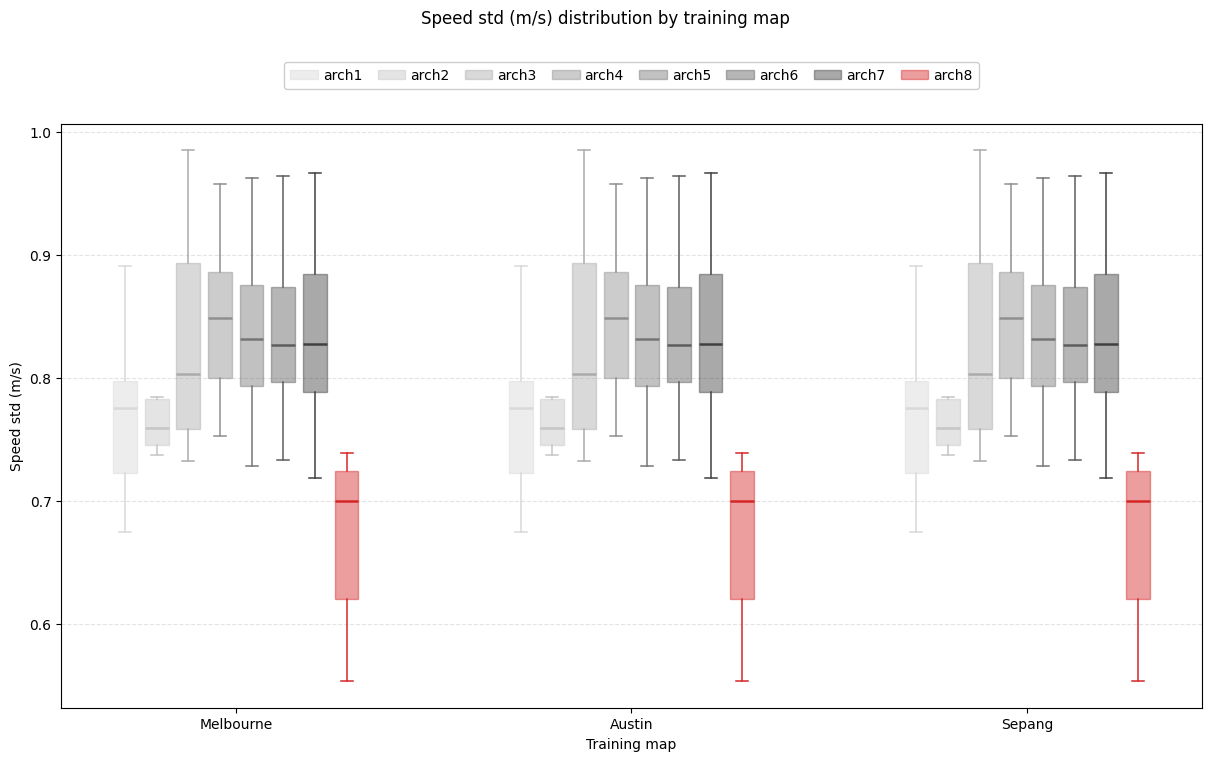

In [35]:
def cross_run_metric_values(run_dirs: list[str | Path], metric_key: str) -> pd.DataFrame:
    frames = [load_run_metric_rows(resolve_compare_run_dir(run_dir), metric_key) for run_dir in run_dirs]
    metric_df = pd.concat(frames, ignore_index=True)
    metric_df["value"] = pd.to_numeric(metric_df["value"], errors="coerce")
    metric_df = metric_df.dropna(subset=["value"])
    return apply_derived_metric_transform(metric_df, metric_key)


def plot_cross_run_metric_boxplots(run_dirs: list[str | Path], metric_key: str) -> None:
    metric_df = cross_run_metric_values(run_dirs, metric_key)
    resolved_dirs = [resolve_compare_run_dir(run_dir) for run_dir in run_dirs]
    run_labels = [run_dir.name for run_dir in resolved_dirs]
    x_labels = [TRAINED_MAP_LABELS.get(run_dir.name, run_dir.name) for run_dir in resolved_dirs]
    x_lookup = {label: idx for idx, label in enumerate(run_labels)}
    arch_order = [f"arch{i}" for i in range(1, 9)]
    arch_offsets = {arch: offset for arch, offset in zip(arch_order, np.linspace(-0.28, 0.28, len(arch_order)))}

    fig = plt.figure(figsize=(12, 7.5), constrained_layout=True)
    grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.12, 0.88])
    legend_ax = fig.add_subplot(grid[0])
    ax = fig.add_subplot(grid[1])
    legend_ax.axis("off")

    handles = []
    labels = []
    for arch in arch_order:
        positions = []
        values = []
        for run_label in run_labels:
            series = metric_df[(metric_df["run_dir"] == run_label) & (metric_df["arch"] == arch)]["value"].dropna().to_numpy()
            if series.size == 0:
                continue
            positions.append(x_lookup[run_label] + arch_offsets[arch])
            values.append(series)
        if not values:
            continue

        color = "#d62728" if arch == "arch8" else plt.cm.Greys(0.25 + 0.55 * (int(arch[4:]) - 1) / 6)
        box = ax.boxplot(
            values,
            positions=positions,
            widths=0.06,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.45},
            medianprops={"color": color, "linewidth": 1.8},
            whiskerprops={"color": color, "linewidth": 1.1},
            capprops={"color": color, "linewidth": 1.1},
        )
        handles.append(box["boxes"][0])
        labels.append(arch)

    metric_label = metric_specs.get(metric_key, {}).get("ylabel", metric_key)
    ax.set_xticks(range(len(run_labels)))
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_ylabel(metric_label)
    ax.set_xlabel("Training map")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    fig.suptitle(f"{metric_label} distribution by training map")
    legend_ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),
        frameon=True,
        framealpha=0.95,
        handletextpad=0.35,
        columnspacing=1.1,
        borderpad=0.45,
    )
    plt.show()


for metric_key in metric_specs:
    plot_cross_run_metric_boxplots(COMPARE_RUN_DIRS, metric_key)


## Composite Safety Metric Box Plot

This plot combines safety-relevant metrics where lower values are better after min-max normalizing each metric across the selected run directories.


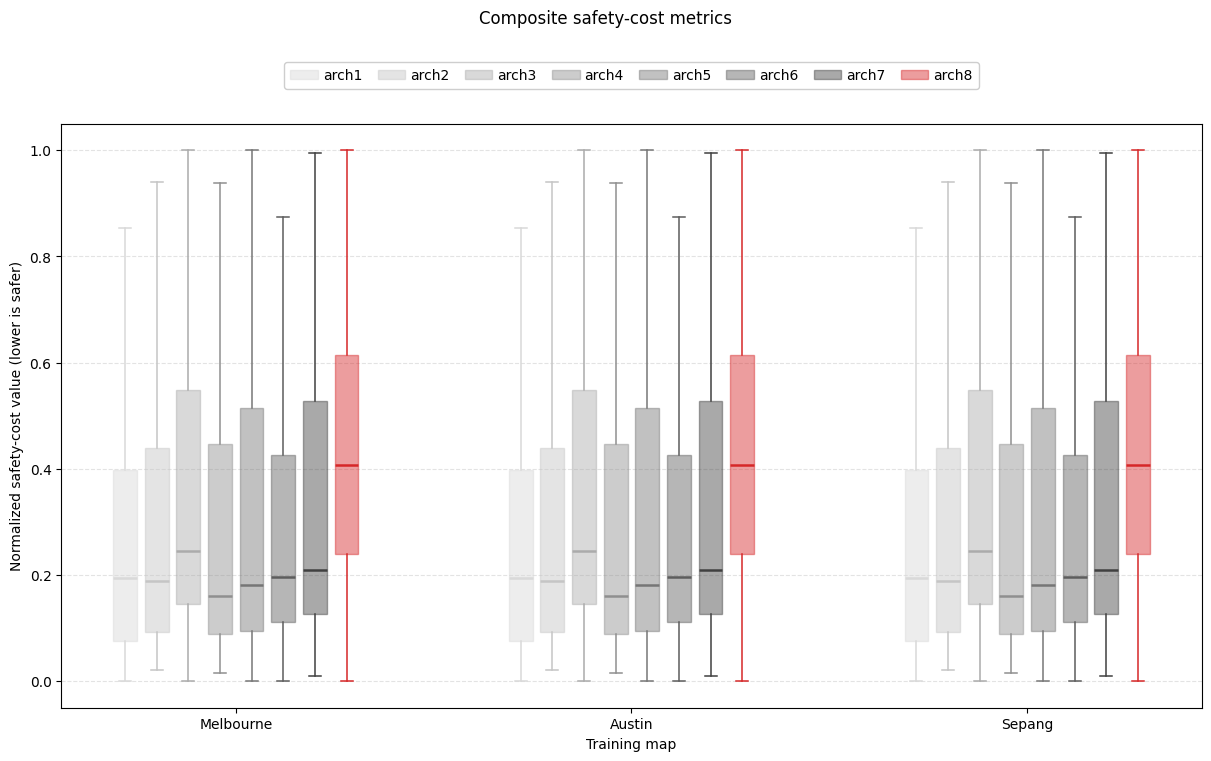

In [36]:
SAFETY_MAXIMIZE_METRICS = [
    "wall_min_distance_m",
]
SAFETY_MINIMIZE_METRICS = [
    "crosstrack_rmse_m",
    "crosstrack_mean_m",
    "crosstrack_std_m",
    "crosstrack_max_m",
    "heading_error_rmse_deg",
    "heading_error_max_deg",
    "wall_min_distance_risk",
    "steering_rate_mean_rad_s",
    "steering_rate_std_rad_s",
    "steering_rate_max_rad_s",
    "speed_mean_m_s",
    "speed_std_m_s",
]


def normalize_metric(series: pd.Series) -> pd.Series:
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(0.5, index=series.index)
    return (series - series.min()) / span


def composite_metric_values(run_dirs: list[str | Path], metric_keys: list[str]) -> pd.DataFrame:
    frames = []
    for metric_key in metric_keys:
        metric_df = cross_run_metric_values(run_dirs, metric_key).copy()
        metric_df["metric"] = metric_key
        metric_df["normalized_value"] = normalize_metric(metric_df["value"])
        frames.append(metric_df)
    return pd.concat(frames, ignore_index=True)


def plot_composite_metric_boxplots(
    run_dirs: list[str | Path],
    metric_keys: list[str],
    title: str,
    ylabel: str,
) -> None:
    metric_df = composite_metric_values(run_dirs, metric_keys)
    resolved_dirs = [resolve_compare_run_dir(run_dir) for run_dir in run_dirs]
    run_labels = [run_dir.name for run_dir in resolved_dirs]
    x_labels = [TRAINED_MAP_LABELS.get(run_dir.name, run_dir.name) for run_dir in resolved_dirs]
    x_lookup = {label: idx for idx, label in enumerate(run_labels)}
    arch_order = [f"arch{i}" for i in range(1, 9)]
    arch_offsets = {arch: offset for arch, offset in zip(arch_order, np.linspace(-0.28, 0.28, len(arch_order)))}

    fig = plt.figure(figsize=(12, 7.5), constrained_layout=True)
    grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.12, 0.88])
    legend_ax = fig.add_subplot(grid[0])
    ax = fig.add_subplot(grid[1])
    legend_ax.axis("off")

    handles = []
    labels = []
    for arch in arch_order:
        positions = []
        values = []
        for run_label in run_labels:
            series = metric_df[(metric_df["run_dir"] == run_label) & (metric_df["arch"] == arch)]["normalized_value"].dropna().to_numpy()
            if series.size == 0:
                continue
            positions.append(x_lookup[run_label] + arch_offsets[arch])
            values.append(series)
        if not values:
            continue

        color = "#d62728" if arch == "arch8" else plt.cm.Greys(0.25 + 0.55 * (int(arch[4:]) - 1) / 6)
        box = ax.boxplot(
            values,
            positions=positions,
            widths=0.06,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops={"facecolor": color, "edgecolor": color, "alpha": 0.45},
            medianprops={"color": color, "linewidth": 1.8},
            whiskerprops={"color": color, "linewidth": 1.1},
            capprops={"color": color, "linewidth": 1.1},
        )
        handles.append(box["boxes"][0])
        labels.append(arch)

    ax.set_xticks(range(len(run_labels)))
    ax.set_xticklabels(x_labels, rotation=0)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Training map")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

    fig.suptitle(title)
    legend_ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(labels),
        frameon=True,
        framealpha=0.95,
        handletextpad=0.35,
        columnspacing=1.1,
        borderpad=0.45,
    )
    plt.show()


plot_composite_metric_boxplots(
    COMPARE_RUN_DIRS,
    SAFETY_MINIMIZE_METRICS,
    title="Composite safety-cost metrics",
    ylabel="Normalized safety-cost value (lower is safer)",
)


## Composite safety-cost improvement number

This uses the same normalized lower-is-better values as the composite boxplot above. The headline number compares the full pooled arch8 distribution against the full pooled arch1-7 distribution.


In [37]:
def percent_lower_than(reference: float, candidate: float) -> float:
    if pd.isna(reference) or pd.isna(candidate) or reference == 0:
        return np.nan
    return 100.0 * (reference - candidate) / reference


def summarize_distribution(series: pd.Series) -> pd.Series:
    return pd.Series(
        {
            "mean_score": series.mean(),
            "median_score": series.median(),
            "q1_score": series.quantile(0.25),
            "q3_score": series.quantile(0.75),
            "min_score": series.min(),
            "max_score": series.max(),
            "n_values": series.count(),
        }
    )


resolved_compare_dirs = [resolve_compare_run_dir(run_dir) for run_dir in COMPARE_RUN_DIRS]
print("Included compare runs:", ", ".join(run_dir.name for run_dir in resolved_compare_dirs))

safety_values = composite_metric_values(resolved_compare_dirs, SAFETY_MINIMIZE_METRICS).copy()
safety_values["group"] = np.where(safety_values["arch"] == "arch8", "arch8", "arch1-7")
print(
    "Composite values:",
    f"{(safety_values['arch'] == 'arch8').sum()} arch8 values and",
    f"{safety_values['arch'].isin([f'arch{i}' for i in range(1, 8)]).sum()} arch1-7 baseline values",
)

# Headline number: pool the whole distribution across all training maps, tracks, and safety-cost metrics.
pooled_summary = (
    safety_values[safety_values["arch"].isin([f"arch{i}" for i in range(1, 9)])]
    .groupby("group")["normalized_value"]
    .apply(summarize_distribution)
    .unstack()
)

arch8_pooled = pooled_summary.loc["arch8"]
baseline_pooled = pooled_summary.loc["arch1-7"]
pooled_mean_improvement = percent_lower_than(baseline_pooled["mean_score"], arch8_pooled["mean_score"])
pooled_q3_improvement = percent_lower_than(baseline_pooled["q3_score"], arch8_pooled["q3_score"])

print(
    "Method: each minimize metric is normalized so 0 is the best observed value and 1 is the worst. "
    "wall_min_distance_risk is included as its own metric and is calculated as "
    "1 - normalized(wall_min_distance_m), while wall_min_distance_m remains available as a maximize metric. "
    "Then all minimize metrics are pooled by group."
)
print(
    "Headline: across the full pooled distribution, arch8's composite safety-cost score is "
    f"{pooled_mean_improvement:.1f}% lower than the pooled arch1-7 baseline "
    f"(arch8 mean {arch8_pooled['mean_score']:.3f} vs baseline mean {baseline_pooled['mean_score']:.3f})."
)
print(
    "Q3 check: arch8's 75th-percentile composite safety-cost score is "
    f"{pooled_q3_improvement:.1f}% lower than the pooled arch1-7 baseline "
    f"(arch8 Q3 {arch8_pooled['q3_score']:.3f} vs baseline Q3 {baseline_pooled['q3_score']:.3f})."
)

# Per-training-map breakdown, using the same full-distribution logic within each training map.
rows = []
for run_dir, run_df in safety_values.groupby("run_dir"):
    arch8_values = run_df[run_df["arch"] == "arch8"]["normalized_value"]
    baseline_values = run_df[run_df["arch"].isin([f"arch{i}" for i in range(1, 8)])]["normalized_value"]

    arch8_summary = summarize_distribution(arch8_values)
    baseline_summary = summarize_distribution(baseline_values)

    baseline_arch_scores = (
        run_df[run_df["arch"].isin([f"arch{i}" for i in range(1, 8)])]
        .groupby("arch")["normalized_value"]
        .mean()
    )
    best_baseline_arch = baseline_arch_scores.idxmin()
    best_baseline_score = baseline_arch_scores.min()

    rows.append(
        {
            "training_map": TRAINED_MAP_LABELS.get(run_dir, run_dir),
            "run_dir": run_dir,
            "arch8_mean_score": arch8_summary["mean_score"],
            "baseline_mean_score": baseline_summary["mean_score"],
            "arch8_vs_baseline_mean_%": percent_lower_than(
                baseline_summary["mean_score"], arch8_summary["mean_score"]
            ),
            "arch8_q3_score": arch8_summary["q3_score"],
            "baseline_q3_score": baseline_summary["q3_score"],
            "arch8_vs_baseline_q3_%": percent_lower_than(
                baseline_summary["q3_score"], arch8_summary["q3_score"]
            ),
            "best_baseline_arch": best_baseline_arch,
            "best_baseline_mean_score": best_baseline_score,
            "arch8_vs_best_baseline_mean_%": percent_lower_than(
                best_baseline_score, arch8_summary["mean_score"]
            ),
            "n_arch8_values": arch8_summary["n_values"],
            "n_baseline_values": baseline_summary["n_values"],
        }
    )

safety_improvement_by_map = pd.DataFrame(rows)

safety_improvement_by_map.style.format(
    {
        "arch8_mean_score": "{:.3f}",
        "baseline_mean_score": "{:.3f}",
        "arch8_vs_baseline_mean_%": "{:+.1f}%",
        "arch8_q3_score": "{:.3f}",
        "baseline_q3_score": "{:.3f}",
        "arch8_vs_baseline_q3_%": "{:+.1f}%",
        "best_baseline_mean_score": "{:.3f}",
        "arch8_vs_best_baseline_mean_%": "{:+.1f}%",
        "n_arch8_values": "{:.0f}",
        "n_baseline_values": "{:.0f}",
    }
)


Included compare runs: 193215, be986b, f926b9
Composite values: 252 arch8 values and 1764 arch1-7 baseline values
Method: each minimize metric is normalized so 0 is the best observed value and 1 is the worst. wall_min_distance_risk is included as its own metric and is calculated as 1 - normalized(wall_min_distance_m), while wall_min_distance_m remains available as a maximize metric. Then all minimize metrics are pooled by group.
Headline: across the full pooled distribution, arch8's composite safety-cost score is -49.8% lower than the pooled arch1-7 baseline (arch8 mean 0.459 vs baseline mean 0.306).
Q3 check: arch8's 75th-percentile composite safety-cost score is -33.2% lower than the pooled arch1-7 baseline (arch8 Q3 0.614 vs baseline Q3 0.461).


,training_map,run_dir,arch8_mean_score,baseline_mean_score,arch8_vs_baseline_mean_%,arch8_q3_score,baseline_q3_score,arch8_vs_baseline_q3_%,best_baseline_arch,best_baseline_mean_score,arch8_vs_best_baseline_mean_%,n_arch8_values,n_baseline_values
0,Melbourne,193215,0.459,0.306,-49.8%,0.614,0.461,-33.2%,arch2,0.278,-64.9%,84,588
1,Austin,be986b,0.459,0.306,-49.8%,0.614,0.461,-33.2%,arch2,0.278,-64.9%,84,588
2,Sepang,f926b9,0.459,0.306,-49.8%,0.614,0.461,-33.2%,arch2,0.278,-64.9%,84,588
